# Real-World Use Cases for Asset Allocators

This section demonstrates practical scenarios that asset allocators commonly encounter, showing how each optimization method handles different portfolio construction challenges.

## Use Case 1: Multi-Asset Class Portfolio (Stocks, Bonds, Commodities)

**Scenario**: An asset allocator wants to construct a diversified portfolio across different asset classes with varying risk characteristics.

**Challenge**: Stocks are high volatility, bonds are low volatility, commodities have different correlation patterns. Traditional mean-variance can be unstable.

**Solution**: Use HRP or Risk Parity to handle the different risk characteristics without requiring return estimates.



In [1]:
import pandas as pd
import numpy as np
import yfinance as yf

from portfolios.portfolio_src import (
    HierarchicalRiskParity,
    ReturnEnhancedHRP,
    RiskParity,
    NestedClusteredOptimization
)

from scipy.optimize import minimize
from portfolios.utilities.portfolio_utilties import (
    portfolio_expected_return, 
    portfolio_volatility,
    weighted_portfolio_returns,
    plot_portfolio_weights_pie
)
from portfolios.utilities.denoising import CovarianceDenoiser

# Note: If you get ImportError for pie chart functions, try restarting the kernel
# The functions are defined in portfolios/utilities/portfolio_utilties.py

# Multi-Asset Class Portfolio Example
# Stocks (high volatility), Bonds (low volatility), Commodities (different correlations), Crypto

# Download data for different asset classes
multi_asset_tickers = {
    'Crypto': ['BTC-USD', 'ETH-USD', 'SOL-USD'],  # Bitcoin, Ethereum, Solana
    'Stocks': ['SPY', 'QQQ', 'IWM'],  # S&P 500, Nasdaq, Small Cap
    'Bonds': ['TLT', 'AGG', 'LQD'],   # Treasury, Aggregate Bond, Corporate Bond
    'Commodities': ['GLD', 'SLV', 'DBA']  # Gold, Silver, Agriculture
}

# Flatten ticker list
all_tickers = [ticker for asset_class in multi_asset_tickers.values() for ticker in asset_class]

# Download data
multi_asset_df = yf.download(all_tickers, start='2015-01-01', progress=False)
multi_asset_returns = multi_asset_df.xs("Close", axis=1, level='Price').pct_change().dropna()

print(f"Multi-Asset Portfolio: {len(multi_asset_returns.columns)} assets")
print(f"Time Period: {multi_asset_returns.index[0].date()} to {multi_asset_returns.index[-1].date()}")
print(f"Number of observations: {len(multi_asset_returns)}")
print("\nAsset Classes:")
for asset_class, tickers in multi_asset_tickers.items():
    print(f"  {asset_class}: {', '.join(tickers)}")

# Calculate volatilities by asset class
print("Annualized Volatilities by Asset Class:")
print("=" * 50)
for asset_class, tickers in multi_asset_tickers.items():
    class_tickers = [t for t in tickers if t in multi_asset_returns.columns]
    if class_tickers:
        class_vols = multi_asset_returns[class_tickers].std() * np.sqrt(252)
        avg_vol = class_vols.mean()
        print(f"{asset_class:12s}: {avg_vol:.2%} (range: {class_vols.min():.2%} - {class_vols.max():.2%})")



/var/folders/d6/_cbljd7n45n13q4v_q1z6b200000gn/T/ipykernel_47938/1379597943.py:41: FutureWarning: YF.download() has changed argument auto_adjust default to True
  multi_asset_df = yf.download(all_tickers, start='2015-01-01', progress=False)


Multi-Asset Portfolio: 12 assets
Time Period: 2020-04-11 to 2025-12-29
Number of observations: 2088

Asset Classes:
  Crypto: BTC-USD, ETH-USD, SOL-USD
  Stocks: SPY, QQQ, IWM
  Bonds: TLT, AGG, LQD
  Commodities: GLD, SLV, DBA
Annualized Volatilities by Asset Class:
Crypto      : 71.92% (range: 48.34% - 102.24%)
Stocks      : 17.82% (range: 14.55% - 19.83%)
Bonds       : 8.29% (range: 4.78% - 13.06%)
Commodities : 16.82% (range: 11.70% - 25.71%)


/var/folders/d6/_cbljd7n45n13q4v_q1z6b200000gn/T/ipykernel_47938/1379597943.py:42: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  multi_asset_returns = multi_asset_df.xs("Close", axis=1, level='Price').pct_change().dropna()


RE-HRP: Information Ratio Allocation
Benchmark: Equal-weighted portfolio of 12 assets
Allocation Metric: Information Ratio
Formula: α = IR_right / (IR_left + IR_right)
Information Ratio = (E[R_portfolio] - E[R_benchmark]) / Tracking_Error
assets if the benchmark performs well. Consider using 'sharpe' instead.

RE-HRP Allocation Summary
Allocation complete. Portfolio weights favor clusters with higher Information Ratios.
Top weighted assets:
  1. ETH-USD: 0.1648 (16.48%)
  2. SOL-USD: 0.1570 (15.70%)
  3. TLT: 0.1000 (10.00%)
  4. BTC-USD: 0.0912 (9.12%)
  5. AGG: 0.0900 (9.00%)
RE-HRP: Information Ratio Allocation
Benchmark: Equal-weighted portfolio of 12 assets
Allocation Metric: Information Ratio
Formula: α = IR_right / (IR_left + IR_right)
Information Ratio = (E[R_portfolio] - E[R_benchmark]) / Tracking_Error
assets if the benchmark performs well. Consider using 'sharpe' instead.

RE-HRP Allocation Summary
Allocation complete. Portfolio weights favor clusters with higher Information

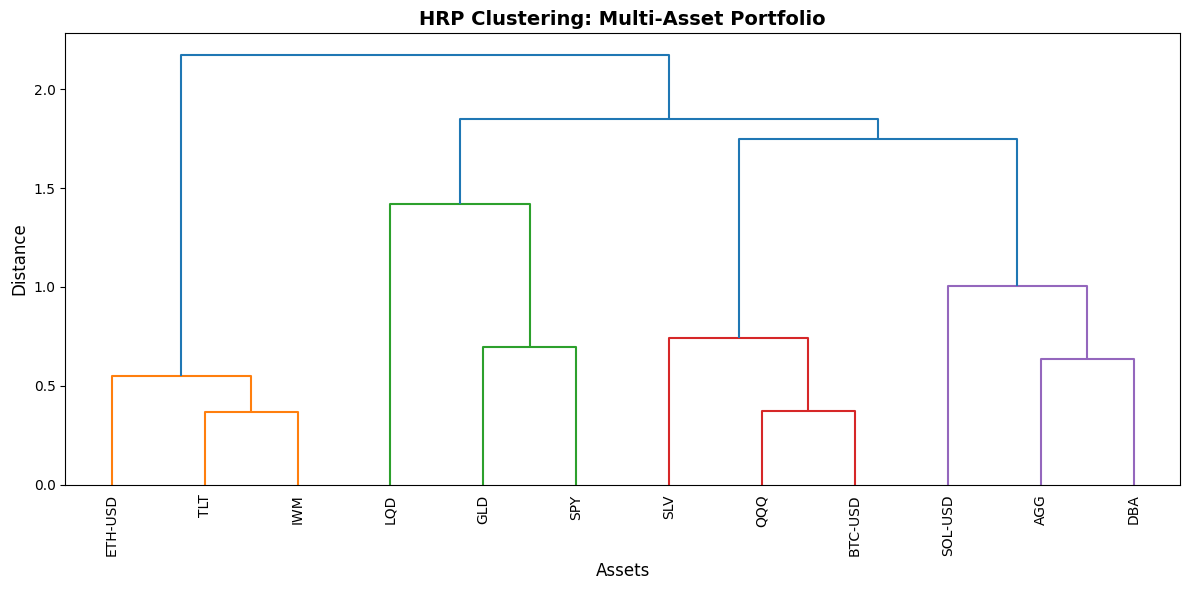


HRP Clustering Insights:
Assets that cluster together have similar correlation patterns.
This helps understand diversification benefits across asset classes.


In [2]:
from matplotlib import pyplot as plt
# Apply HRP to multi-asset portfolio
multi_hrp = HierarchicalRiskParity()
multi_hrp.fit(multi_asset_returns)
multi_hrp_weights = multi_hrp.predict()

# Apply Risk Parity
multi_rp = RiskParity()
multi_rp.fit(multi_asset_returns)
multi_rp_weights = multi_rp.predict()

# Apply NCO to multi-asset portfolio
multi_nco = NestedClusteredOptimization(n_clusters=3)
multi_nco.fit(multi_asset_returns)
multi_nco_weights = multi_nco.predict()

# Apply RE-HRP with Low Volatility Constraint
# min_return_threshold prevents over-allocation to low-volatility assets (e.g., TLT)
# while still favoring clusters with good Information Ratios
multi_re_hrp_lowvol = ReturnEnhancedHRP(
    linkage_method='ward',
    risk_free_rate=0.02,
    allocation_metric='information_ratio',
    verbose=False,
    min_return_threshold=0.05,  # 5% annualized minimum return
    min_tracking_error=0.01
)
multi_re_hrp_lowvol.fit(multi_asset_returns)
multi_re_hrp_lowvol_weights = multi_re_hrp_lowvol.predict()

# Mean-Variance Optimization
# Calculate expected returns and covariance matrix
expected_returns = multi_asset_returns.mean().values
cov_matrix = multi_asset_returns.cov().values
risk_free_rate = 0.02 / 252  # Daily risk-free rate

# Max Sharpe
def negative_sharpe(weights):
    port_return = expected_returns.T @ weights
    port_vol = np.sqrt(weights.T @ cov_matrix @ weights)
    if port_vol == 0:
        return 1e10
    sharpe = (port_return - risk_free_rate) / port_vol
    return -sharpe

constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0})
bounds = tuple((0, 1) for _ in range(len(multi_asset_returns.columns)))
initial_weights = np.ones(len(multi_asset_returns.columns)) / len(multi_asset_returns.columns)

mv_maxsharpe_result = minimize(negative_sharpe, initial_weights, method='SLSQP',
                               bounds=bounds, constraints=constraints)
mv_maxsharpe_weights = mv_maxsharpe_result.x

# Min Variance
def portfolio_variance(weights):
    return weights.T @ cov_matrix @ weights

mv_minvar_result = minimize(portfolio_variance, initial_weights, method='SLSQP',
                            bounds=bounds, constraints=constraints)
mv_minvar_weights = mv_minvar_result.x

# Leveraged Portfolios (1.5x)
# Risk Parity - built-in support
multi_rp_lev = RiskParity(leverage=1.5)
multi_rp_lev.fit(multi_asset_returns)
multi_rp_lev_weights = multi_rp_lev.predict()

# Others - scale weights
multi_hrp_lev_weights = multi_hrp_weights * 1.5
multi_nco_lev_weights = multi_nco_weights * 1.5
multi_re_hrp_lowvol_lev_weights = multi_re_hrp_lowvol_weights * 1.5
mv_maxsharpe_lev_weights = mv_maxsharpe_weights * 1.5
mv_minvar_lev_weights = mv_minvar_weights * 1.5

# Denoised Portfolio Variants (using constant_residual method)
denoiser = CovarianceDenoiser()
num_obs = len(multi_asset_returns)

# HRP with Denoising
multi_hrp_denoise = HierarchicalRiskParity(denoise=True, denoising_method="constant_residual")
multi_hrp_denoise.fit(multi_asset_returns)
multi_hrp_denoise_weights = multi_hrp_denoise.predict()

# RE-HRP with Denoising
multi_re_hrp_denoise = ReturnEnhancedHRP(
    linkage_method='ward',
    risk_free_rate=0.02,
    allocation_metric='information_ratio',
    verbose=False,
    min_return_threshold=0.05,
    min_tracking_error=0.01,
    denoise=True,
    denoising_method="constant_residual"
)
multi_re_hrp_denoise.fit(multi_asset_returns)
multi_re_hrp_denoise_weights = multi_re_hrp_denoise.predict()

# Mean-Variance with Denoised Covariance
# Get correlation matrix and volatilities for denoising
corr_matrix = multi_asset_returns.corr()
daily_vols = multi_asset_returns.std()

# Denoise correlation matrix
corr_denoised = denoiser.denoise(
    corr_matrix,
    method="constant_residual",
    num_observations=num_obs,
    matrix_type="correlation"
)

# Rescale to covariance: Σ = D R̂ D
cov_denoised = denoiser._rescale_to_covariance(corr_denoised, daily_vols)
denoised_cov_matrix = cov_denoised.values
denoised_expected_returns = multi_asset_returns.mean().values

def mv_denoise_negative_sharpe(weights):
    port_return = denoised_expected_returns.T @ weights
    port_vol = np.sqrt(weights.T @ denoised_cov_matrix @ weights)
    if port_vol == 0:
        return 1e10
    sharpe = (port_return - risk_free_rate) / port_vol
    return -sharpe

mv_maxsharpe_denoise_result = minimize(mv_denoise_negative_sharpe, initial_weights, 
                                      method='SLSQP', bounds=bounds, constraints=constraints)
mv_maxsharpe_denoise_weights = mv_maxsharpe_denoise_result.x

def mv_denoise_portfolio_variance(weights):
    return weights.T @ denoised_cov_matrix @ weights

mv_minvar_denoise_result = minimize(mv_denoise_portfolio_variance, initial_weights,
                                   method='SLSQP', bounds=bounds, constraints=constraints)
mv_minvar_denoise_weights = mv_minvar_denoise_result.x

# Leveraged Denoised Portfolios (1.5x)
multi_hrp_denoise_lev_weights = multi_hrp_denoise_weights * 1.5
multi_re_hrp_denoise_lev_weights = multi_re_hrp_denoise_weights * 1.5
mv_maxsharpe_denoise_lev_weights = mv_maxsharpe_denoise_weights * 1.5
mv_minvar_denoise_lev_weights = mv_minvar_denoise_weights * 1.5

# Create weights dictionary for all methods (unleveraged, leveraged, and denoised variants)
# This will be used for pie chart visualizations
weights_dict = {
    'Equal-Weighted': np.ones(len(multi_asset_returns.columns)) / len(multi_asset_returns.columns),
    'HRP': multi_hrp_weights,
    'Risk Parity': multi_rp_weights,
    'NCO': multi_nco_weights,
    'RE-HRP (Low Vol)': multi_re_hrp_lowvol_weights,
    'MV Max Sharpe': mv_maxsharpe_weights,
    'MV Min Var': mv_minvar_weights,
    # Leveraged versions
    'HRP (1.5x)': multi_hrp_lev_weights,
    'Risk Parity (1.5x)': multi_rp_lev_weights,
    'NCO (1.5x)': multi_nco_lev_weights,
    'RE-HRP Low Vol (1.5x)': multi_re_hrp_lowvol_lev_weights,
    'MV Max Sharpe (1.5x)': mv_maxsharpe_lev_weights,
    'MV Min Var (1.5x)': mv_minvar_lev_weights,
    # Denoised versions (constant_residual)
    'HRP (Denoised)': multi_hrp_denoise_weights,
    'RE-HRP (Denoised)': multi_re_hrp_denoise_weights,
    'MV Max Sharpe (Denoised)': mv_maxsharpe_denoise_weights,
    'MV Min Var (Denoised)': mv_minvar_denoise_weights,
    # Leveraged Denoised versions
    'HRP (Denoised, 1.5x)': multi_hrp_denoise_lev_weights,
    'RE-HRP (Denoised, 1.5x)': multi_re_hrp_denoise_lev_weights,
    'MV Max Sharpe (Denoised, 1.5x)': mv_maxsharpe_denoise_lev_weights,
    'MV Min Var (Denoised, 1.5x)': mv_minvar_denoise_lev_weights
}

# Weight comparison tables removed - now using pie charts in Cell 4

# Visualize HRP clustering for multi-asset portfolio
fig, ax = multi_hrp.plot_dendrogram()
plt.title('HRP Clustering: Multi-Asset Portfolio', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Check which assets cluster together
print("\nHRP Clustering Insights:")
print("Assets that cluster together have similar correlation patterns.")
print("This helps understand diversification benefits across asset classes.")



## Use Case 2: Sector-Based Equity Portfolio

**Scenario**: An equity portfolio manager wants to allocate across different sectors while managing risk.

**Challenge**: Sectors have different volatilities and correlations. Some sectors (e.g., Tech) are more volatile than others (e.g., Utilities).

**Solution**: Use Risk Parity to ensure each sector contributes equally to portfolio risk, or NCO to cluster similar sectors first.


In [3]:
# Sector-Based Equity Portfolio Example
# Download sector-based stocks
sector_tickers = {
    'Technology': ['AAPL', 'MSFT', 'NVDA'],
    'Finance': ['JPM', 'BAC', 'GS'],
    'Healthcare': ['JNJ', 'PFE', 'UNH'],
    'Consumer': ['KO', 'PG', 'WMT']
}

all_sector_tickers = [ticker for sector in sector_tickers.values() for ticker in sector]
sector_df = yf.download(all_sector_tickers, start='2015-01-01', progress=False)
sector_returns = sector_df.xs("Close", axis=1, level='Price').pct_change().dropna()

print(f"Sector Portfolio: {len(sector_returns.columns)} stocks across {len(sector_tickers)} sectors")

# Apply all methods
sector_hrp = HierarchicalRiskParity()
sector_hrp.fit(sector_returns)
sector_hrp_weights = sector_hrp.predict()

sector_rp = RiskParity()
sector_rp.fit(sector_returns)
sector_rp_weights = sector_rp.predict()

sector_nco = NestedClusteredOptimization(n_clusters=4)
sector_nco.fit(sector_returns)
sector_nco_weights = sector_nco.predict()

# Apply RE-HRP with Low Volatility Constraint
sector_re_hrp_lowvol = ReturnEnhancedHRP(
    linkage_method='ward',
    risk_free_rate=0.02,
    allocation_metric='information_ratio',
    verbose=False,
    min_return_threshold=0.05,
    min_tracking_error=0.01
)
sector_re_hrp_lowvol.fit(sector_returns)
sector_re_hrp_lowvol_weights = sector_re_hrp_lowvol.predict()

# Mean-Variance Optimization
sector_expected_returns = sector_returns.mean().values
sector_cov_matrix = sector_returns.cov().values
sector_risk_free_rate = 0.02 / 252

def sector_negative_sharpe(weights):
    port_return = sector_expected_returns.T @ weights
    port_vol = np.sqrt(weights.T @ sector_cov_matrix @ weights)
    if port_vol == 0:
        return 1e10
    sharpe = (port_return - sector_risk_free_rate) / port_vol
    return -sharpe

sector_constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0})
sector_bounds = tuple((0, 1) for _ in range(len(sector_returns.columns)))
sector_initial_weights = np.ones(len(sector_returns.columns)) / len(sector_returns.columns)

sector_mv_maxsharpe_result = minimize(sector_negative_sharpe, sector_initial_weights, method='SLSQP',
                                     bounds=sector_bounds, constraints=sector_constraints)
sector_mv_maxsharpe_weights = sector_mv_maxsharpe_result.x

def sector_portfolio_variance(weights):
    return weights.T @ sector_cov_matrix @ weights

sector_mv_minvar_result = minimize(sector_portfolio_variance, sector_initial_weights, method='SLSQP',
                                   bounds=sector_bounds, constraints=sector_constraints)
sector_mv_minvar_weights = sector_mv_minvar_result.x

# Leveraged Portfolios (1.5x)
sector_rp_lev = RiskParity(leverage=1.5)
sector_rp_lev.fit(sector_returns)
sector_rp_lev_weights = sector_rp_lev.predict()
sector_hrp_lev_weights = sector_hrp_weights * 1.5
sector_nco_lev_weights = sector_nco_weights * 1.5
sector_re_hrp_lowvol_lev_weights = sector_re_hrp_lowvol_weights * 1.5
sector_mv_maxsharpe_lev_weights = sector_mv_maxsharpe_weights * 1.5
sector_mv_minvar_lev_weights = sector_mv_minvar_weights * 1.5


/var/folders/d6/_cbljd7n45n13q4v_q1z6b200000gn/T/ipykernel_47938/3885157858.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sector_df = yf.download(all_sector_tickers, start='2015-01-01', progress=False)


Sector Portfolio: 12 stocks across 4 sectors
RE-HRP: Information Ratio Allocation
Benchmark: Equal-weighted portfolio of 12 assets
Allocation Metric: Information Ratio
Formula: α = IR_right / (IR_left + IR_right)
Information Ratio = (E[R_portfolio] - E[R_benchmark]) / Tracking_Error
assets if the benchmark performs well. Consider using 'sharpe' instead.

RE-HRP Allocation Summary
Allocation complete. Portfolio weights favor clusters with higher Information Ratios.
Top weighted assets:
  1. NVDA: 0.2939 (29.39%)
  2. MSFT: 0.2288 (22.88%)
  3. AAPL: 0.1566 (15.66%)
  4. PFE: 0.0553 (5.53%)
  5. WMT: 0.0498 (4.98%)



USE CASE 2: SECTOR-BASED EQUITY PORTFOLIO - PIE CHART VISUALIZATIONS


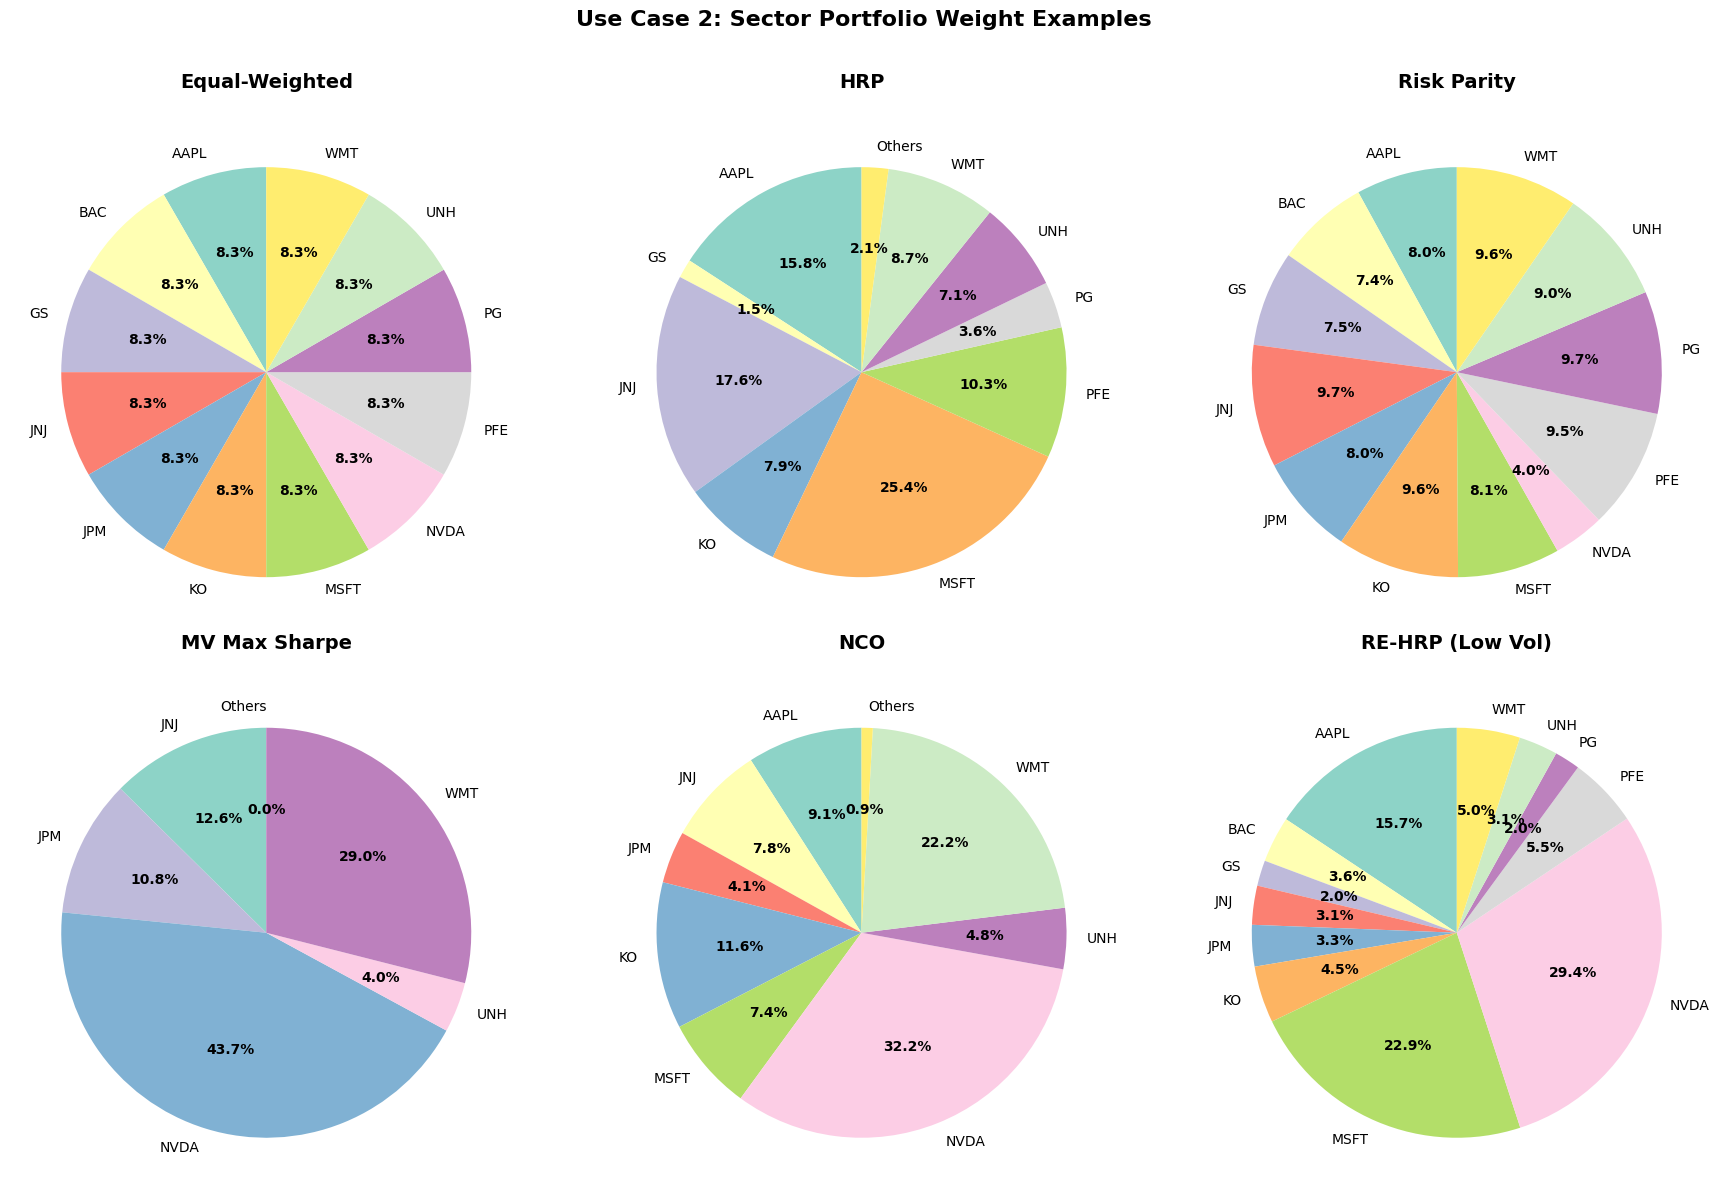


Note: 13 total methods available for Use Case 2.

USE CASE 2: LEVERAGED vs UNLEVERAGED COMPARISON
       Method Unleveraged Return Leveraged Return Unleveraged Vol Leveraged Vol Unleveraged Sharpe Leveraged Sharpe
          HRP           17.8493%         17.8493%        16.9016%      16.9016%             0.9377           0.9377
  Risk Parity           17.8111%         17.7029%        16.6047%      16.1558%             0.9522           0.9720
          NCO           33.1557%         33.1557%        22.6426%      22.6426%             1.3760           1.3760
MV Max Sharpe           38.1296%         38.1296%        25.6646%      25.6646%             1.4078           1.4078
   MV Min Var           20.4802%         20.4802%        17.6048%      17.6048%             1.0497           1.0497

Note: Leveraged (1.5x) portfolios scale weights by 1.5x, increasing both returns and volatility proportionally.


In [4]:
# Pie Chart Visualizations for Use Case 2 (Sector-Based Equity Portfolio)
# Create weights dictionary for sector portfolio
sector_weights_dict = {
    'Equal-Weighted': np.ones(len(sector_returns.columns)) / len(sector_returns.columns),
    'HRP': sector_hrp_weights,
    'Risk Parity': sector_rp_weights,
    'NCO': sector_nco_weights,
    'RE-HRP (Low Vol)': sector_re_hrp_lowvol_weights,
    'MV Max Sharpe': sector_mv_maxsharpe_weights,
    'MV Min Var': sector_mv_minvar_weights,
    # Leveraged versions
    'HRP (1.5x)': sector_hrp_lev_weights,
    'Risk Parity (1.5x)': sector_rp_lev_weights,
    'NCO (1.5x)': sector_nco_lev_weights,
    'RE-HRP Low Vol (1.5x)': sector_re_hrp_lowvol_lev_weights,
    'MV Max Sharpe (1.5x)': sector_mv_maxsharpe_lev_weights,
    'MV Min Var (1.5x)': sector_mv_minvar_lev_weights
}

# Show example pie charts for key methods
print("\n" + "=" * 80)
print("USE CASE 2: SECTOR-BASED EQUITY PORTFOLIO - PIE CHART VISUALIZATIONS")
print("=" * 80)

example_methods_sector = ['Equal-Weighted', 'HRP', 'Risk Parity', 'MV Max Sharpe', 'NCO', 'RE-HRP (Low Vol)']
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, method_name in enumerate(example_methods_sector):
    if method_name in sector_weights_dict:
        weights = sector_weights_dict[method_name]
        plot_portfolio_weights_pie(weights, sector_returns.columns, 
                                   f'{method_name}', ax=axes[idx])

plt.suptitle('Use Case 2: Sector Portfolio Weight Examples', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

print(f"\nNote: {len(sector_weights_dict)} total methods available for Use Case 2.")

# Leveraged vs Unleveraged Comparison for Use Case 2 (Sector Portfolio)
print("\n" + "=" * 80)
print("USE CASE 2: LEVERAGED vs UNLEVERAGED COMPARISON")
print("=" * 80)

# Create comparison table
leveraged_comparison_sector = []
for method_base in ['HRP', 'Risk Parity', 'NCO', 'RE-HRP (Low Vol)', 'MV Max Sharpe', 'MV Min Var']:
    unleveraged_name = method_base
    leveraged_name = f"{method_base} (1.5x)"
    
    if unleveraged_name in sector_weights_dict and leveraged_name in sector_weights_dict:
        unleveraged_weights = sector_weights_dict[unleveraged_name]
        leveraged_weights = sector_weights_dict[leveraged_name]
        
        # Calculate metrics
        unleveraged_ret = portfolio_expected_return(sector_returns, unleveraged_weights) * 252
        unleveraged_vol = portfolio_volatility(sector_returns, unleveraged_weights) * np.sqrt(252)
        unleveraged_sharpe = (unleveraged_ret - 0.02) / unleveraged_vol if unleveraged_vol > 0 else 0
        
        leveraged_ret = portfolio_expected_return(sector_returns, leveraged_weights) * 252
        leveraged_vol = portfolio_volatility(sector_returns, leveraged_weights) * np.sqrt(252)
        leveraged_sharpe = (leveraged_ret - 0.02) / leveraged_vol if leveraged_vol > 0 else 0
        
        leveraged_comparison_sector.append({
            'Method': method_base,
            'Unleveraged Return': f"{unleveraged_ret:.4%}",
            'Leveraged Return': f"{leveraged_ret:.4%}",
            'Unleveraged Vol': f"{unleveraged_vol:.4%}",
            'Leveraged Vol': f"{leveraged_vol:.4%}",
            'Unleveraged Sharpe': f"{unleveraged_sharpe:.4f}",
            'Leveraged Sharpe': f"{leveraged_sharpe:.4f}"
        })

comparison_df_sector = pd.DataFrame(leveraged_comparison_sector)
print(comparison_df_sector.to_string(index=False))
print("\nNote: Leveraged (1.5x) portfolios scale weights by 1.5x, increasing both returns and volatility proportionally.")


In [5]:
# NOTE: Leveraged vs Unleveraged comparison for Use Case 2 has been moved to the end of the pie chart cell above
# This ensures sector_weights_dict is created before the comparison runs



PORTFOLIO WEIGHT VISUALIZATIONS

1. Example Pie Charts - Key Methods:
--------------------------------------------------------------------------------
Showing representative examples. To view all methods, use: plot_portfolio_weights_pie(weights, asset_names, title)
All methods are available in weights_dict dictionary.


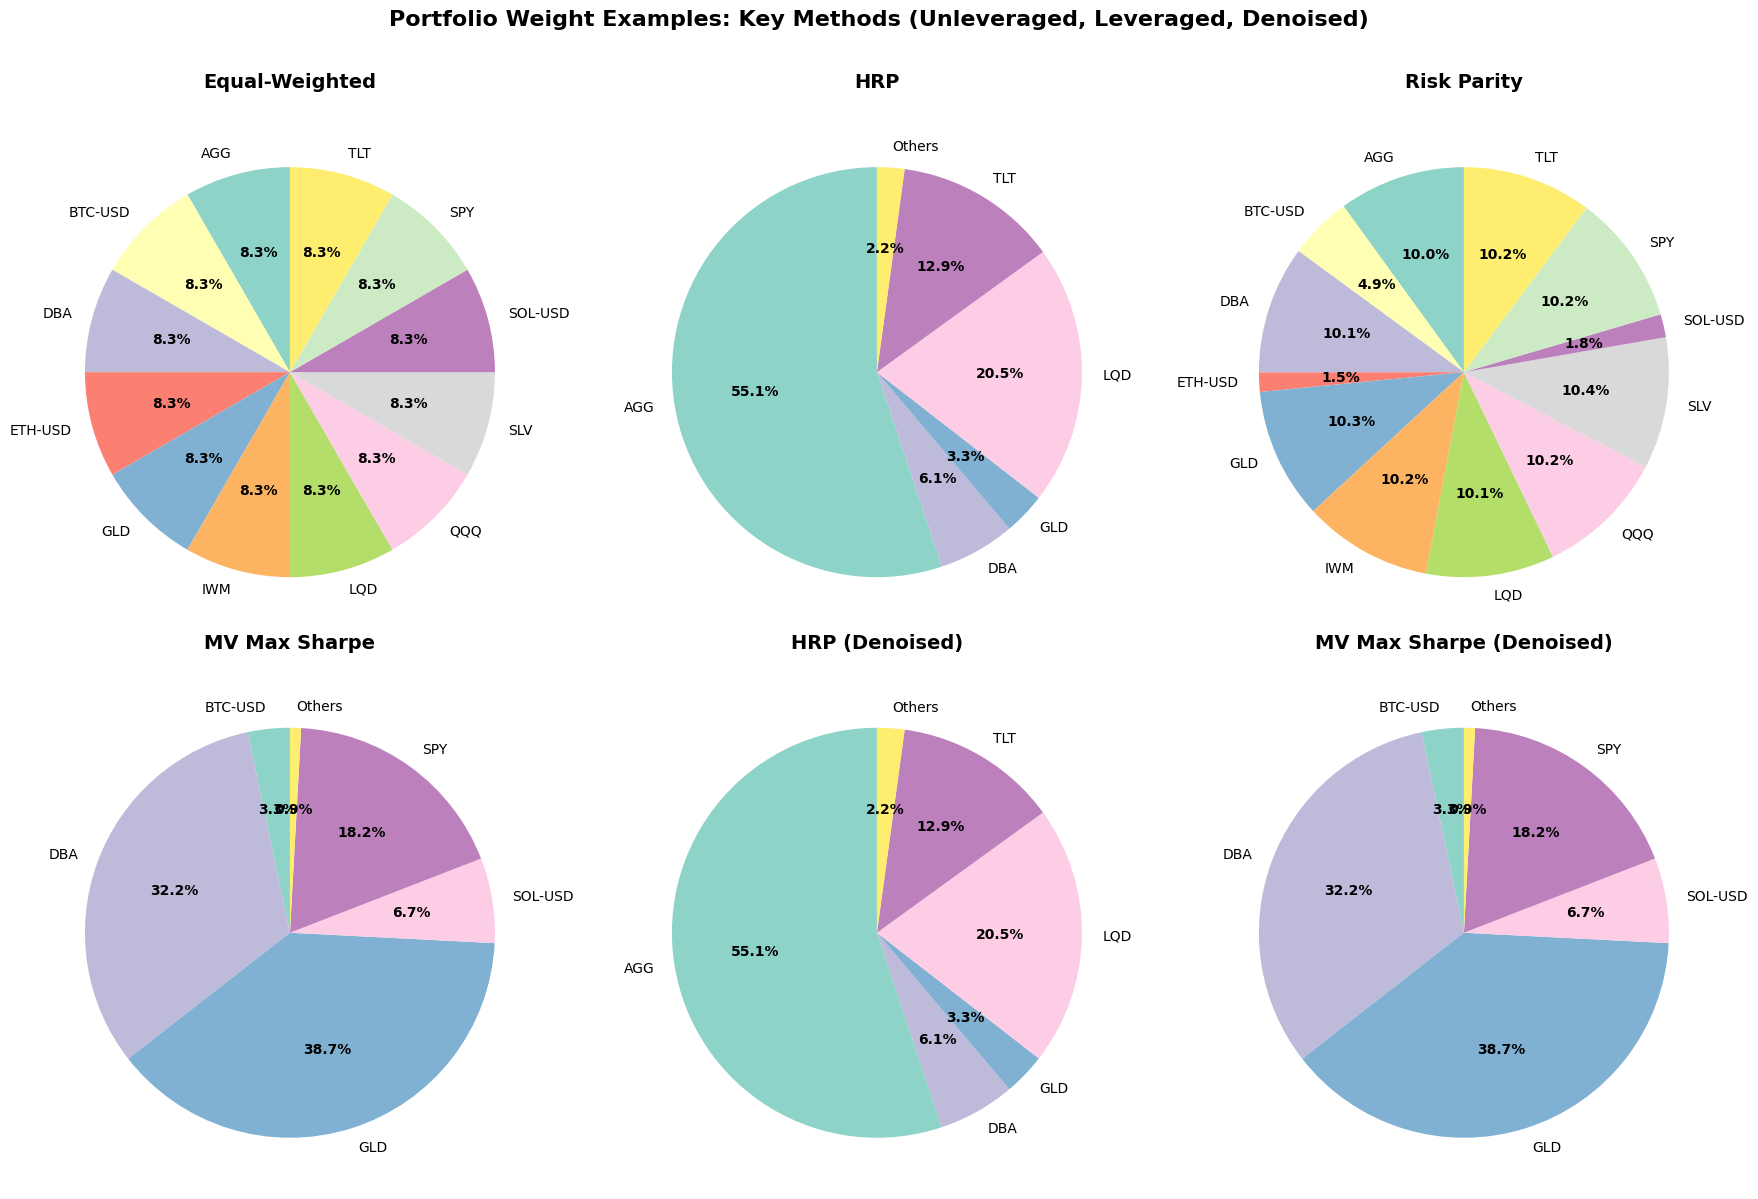


Note: 21 total methods available. Use weights_dict to access any method.
Example: plot_portfolio_weights_pie(weights_dict['HRP (1.5x)'], multi_asset_returns.columns, 'HRP Leveraged')

3. Risk-Return Comparison Table
--------------------------------------------------------------------------------
                        Method Return (Annualized) Volatility (Annualized) Sharpe Ratio
                Equal-Weighted            24.2534%                19.0193%       1.1700
                           HRP             0.9818%                 5.8502%      -0.1740
                   Risk Parity            13.3008%                10.7529%       1.0509
                           NCO            17.6449%                11.0899%       1.4107
              RE-HRP (Low Vol)            34.6485%                29.0679%       1.1232
                 MV Max Sharpe            19.3672%                12.1152%       1.4335
                    MV Min Var            12.4128%                10.6519%       0.977

In [8]:
# Pie Chart Visualizations for Portfolio Weights
# Replace weight tables with visual pie charts
# Note: weights_dict is created in Cell 2 after all portfolio weights are computed

# Safety check: Ensure weights_dict exists (Cell 2 must be run first)
if 'weights_dict' not in globals():
    raise NameError(
        "weights_dict is not defined. Please run Cell 1 and Cell 2 first to create all portfolio weights."
    )

print("\n" + "=" * 80)
print("PORTFOLIO WEIGHT VISUALIZATIONS")
print("=" * 80)

# 1. Example Pie Charts (showing a few key methods)
print("\n1. Example Pie Charts - Key Methods:")
print("-" * 80)
print("Showing representative examples. To view all methods, use: plot_portfolio_weights_pie(weights, asset_names, title)")
print("All methods are available in weights_dict dictionary.")

# Show a few key examples
example_methods = ['Equal-Weighted', 'HRP', 'Risk Parity', 'MV Max Sharpe', 'HRP (Denoised)', 'MV Max Sharpe (Denoised)']
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, method_name in enumerate(example_methods):
    if method_name in weights_dict:
        weights = weights_dict[method_name]
        plot_portfolio_weights_pie(weights, multi_asset_returns.columns, 
                                   f'{method_name}', ax=axes[idx])

plt.suptitle('Portfolio Weight Examples: Key Methods (Unleveraged, Leveraged, Denoised)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

print(f"\nNote: {len(weights_dict)} total methods available. Use weights_dict to access any method.")
print("Example: plot_portfolio_weights_pie(weights_dict['HRP (1.5x)'], multi_asset_returns.columns, 'HRP Leveraged')")

# 3. Comparison Table: Risk-Return Metrics for All Methods
print("\n3. Risk-Return Comparison Table")
print("-" * 80)
# Calculate returns and volatilities for all methods
comparison_data = []
for method_name, weights in weights_dict.items():
    ret = portfolio_expected_return(multi_asset_returns, weights) * 252
    vol = portfolio_volatility(multi_asset_returns, weights) * np.sqrt(252)
    sharpe = (ret - 0.02) / vol if vol > 0 else 0
    comparison_data.append({
        'Method': method_name,
        'Return (Annualized)': f"{ret:.4%}",
        'Volatility (Annualized)': f"{vol:.4%}",
        'Sharpe Ratio': f"{sharpe:.4f}"
    })

comparison_table = pd.DataFrame(comparison_data)
print(comparison_table.to_string(index=False))





In [9]:
# View cluster assignments (NCO was already created in previous cell)
cluster_assignments = sector_nco.get_cluster_assignments()
print("\nNCO Cluster Assignments:")
print("=" * 40)
for cluster_id in sorted(set(cluster_assignments.values())):
    assets_in_cluster = [asset for asset, cid in cluster_assignments.items() if cid == cluster_id]
    print(f"Cluster {cluster_id}: {', '.join(assets_in_cluster)}")

# Compare sector weights
print("\nSector Weights Comparison:")
print("=" * 50)
sector_comparison = {}
for sector, tickers in sector_tickers.items():
    rp_weight = sum(sector_rp_weights[sector_returns.columns.get_loc(t)] 
                   for t in tickers if t in sector_returns.columns)
    nco_weight = sum(sector_nco_weights[sector_returns.columns.get_loc(t)] 
                    for t in tickers if t in sector_returns.columns)
    sector_comparison[sector] = {'Risk Parity': rp_weight, 'NCO': nco_weight}

sector_comp_df = pd.DataFrame(sector_comparison).T
print(sector_comp_df.round(4))



NCO Cluster Assignments:
Cluster 1: JNJ, PFE, UNH
Cluster 2: KO, PG, WMT
Cluster 3: BAC, GS, JPM
Cluster 4: AAPL, MSFT, NVDA

Sector Weights Comparison:
            Risk Parity     NCO
Technology       0.2006  0.4863
Finance          0.2285  0.0490
Healthcare       0.2821  0.1266
Consumer         0.2888  0.3381


## Use Case 3: International Portfolio (Geographic Diversification)

**Scenario**: A global allocator wants to diversify across different geographic regions.

**Challenge**: Different countries/regions have different risk-return profiles and correlations. Currency effects and economic cycles vary.

**Solution**: Use HRP to naturally cluster by geographic/correlation patterns, or Risk Parity to balance risk across regions.


In [10]:
# International Portfolio Example
# ETFs representing different geographic regions

international_tickers = {
    'US': ['SPY'],           # S&P 500
    'Europe': ['VGK'],       # Europe ETF
    'Asia': ['VPL'],         # Asia-Pacific ETF
    'Emerging': ['VWO'],     # Emerging Markets ETF
    'Japan': ['EWJ']         # Japan ETF
}

intl_ticker_list = [ticker for region in international_tickers.values() for ticker in region]
intl_df = yf.download(intl_ticker_list, start='2015-01-01', progress=False)
intl_returns = intl_df.xs("Close", axis=1, level='Price').pct_change().dropna()

print(f"International Portfolio: {len(intl_returns.columns)} regions")
print(f"Regions: {', '.join(international_tickers.keys())}")

# Apply all three methods
intl_hrp = HierarchicalRiskParity()
intl_hrp.fit(intl_returns)
intl_hrp_weights = intl_hrp.predict()

intl_rp = RiskParity()
intl_rp.fit(intl_returns)
intl_rp_weights = intl_rp.predict()

intl_nco = NestedClusteredOptimization(n_clusters=3)
intl_nco.fit(intl_returns)
intl_nco_weights = intl_nco.predict()

# Apply RE-HRP with Low Volatility Constraint
intl_re_hrp_lowvol = ReturnEnhancedHRP(
    linkage_method='ward',
    risk_free_rate=0.02,
    allocation_metric='information_ratio',
    verbose=False,
    min_return_threshold=0.05,
    min_tracking_error=0.01
)
intl_re_hrp_lowvol.fit(intl_returns)
intl_re_hrp_lowvol_weights = intl_re_hrp_lowvol.predict()

# Mean-Variance Optimization
intl_expected_returns = intl_returns.mean().values
intl_cov_matrix = intl_returns.cov().values
intl_risk_free_rate = 0.02 / 252

def intl_negative_sharpe(weights):
    port_return = intl_expected_returns.T @ weights
    port_vol = np.sqrt(weights.T @ intl_cov_matrix @ weights)
    if port_vol == 0:
        return 1e10
    sharpe = (port_return - intl_risk_free_rate) / port_vol
    return -sharpe

intl_constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0})
intl_bounds = tuple((0, 1) for _ in range(len(intl_returns.columns)))
intl_initial_weights = np.ones(len(intl_returns.columns)) / len(intl_returns.columns)

intl_mv_maxsharpe_result = minimize(intl_negative_sharpe, intl_initial_weights, method='SLSQP',
                                    bounds=intl_bounds, constraints=intl_constraints)
intl_mv_maxsharpe_weights = intl_mv_maxsharpe_result.x

def intl_portfolio_variance(weights):
    return weights.T @ intl_cov_matrix @ weights

intl_mv_minvar_result = minimize(intl_portfolio_variance, intl_initial_weights, method='SLSQP',
                                 bounds=intl_bounds, constraints=intl_constraints)
intl_mv_minvar_weights = intl_mv_minvar_result.x

# Leveraged Portfolios (1.5x)
intl_rp_lev = RiskParity(leverage=1.5)
intl_rp_lev.fit(intl_returns)
intl_rp_lev_weights = intl_rp_lev.predict()
intl_hrp_lev_weights = intl_hrp_weights * 1.5
intl_nco_lev_weights = intl_nco_weights * 1.5
intl_re_hrp_lowvol_lev_weights = intl_re_hrp_lowvol_weights * 1.5
intl_mv_maxsharpe_lev_weights = intl_mv_maxsharpe_weights * 1.5
intl_mv_minvar_lev_weights = intl_mv_minvar_weights * 1.5

# Compare regional allocations
print("\nRegional Allocation Comparison:")
print("=" * 60)
regional_weights = {}
for region, tickers in international_tickers.items():
    ticker = tickers[0]  # Each region has one ETF
    if ticker in intl_returns.columns:
        idx = intl_returns.columns.get_loc(ticker)
        regional_weights[region] = {
            'HRP': intl_hrp_weights[idx],
            'Risk Parity': intl_rp_weights[idx],
            'NCO': intl_nco_weights[idx],
            'RE-HRP (Low Vol)': intl_re_hrp_lowvol_weights[idx],
            'MV Max Sharpe': intl_mv_maxsharpe_weights[idx],
            'MV Min Var': intl_mv_minvar_weights[idx]
        }

regional_df = pd.DataFrame(regional_weights).T
print(regional_df.round(4))
print("\nSum check:")
print(regional_df.sum().round(6))


# Performance comparison for international portfolio
print("\nPerformance Metrics (Annualized):")
print("=" * 60)

methods = {
    'HRP': (intl_hrp, intl_hrp_weights),
    'Risk Parity': (intl_rp, intl_rp_weights),
    'NCO': (intl_nco, intl_nco_weights),
    'RE-HRP (Low Vol)': (intl_re_hrp_lowvol, intl_re_hrp_lowvol_weights),
    'MV Max Sharpe': (None, intl_mv_maxsharpe_weights),
    'MV Min Var': (None, intl_mv_minvar_weights)
}

perf_comparison = []
for method_name, (optimizer, weights) in methods.items():
    if optimizer is not None:
        ret, vol, sharpe = optimizer.portfolio_performance(risk_free_rate=0.02)
    else:
        # Calculate for Mean-Variance manually
        ret = portfolio_expected_return(intl_returns, weights) * 252
        vol = portfolio_volatility(intl_returns, weights) * np.sqrt(252)
        sharpe = (ret - 0.02) / vol if vol > 0 else 0
    perf_comparison.append({
        'Method': method_name,
        'Return': f"{ret:.2%}",
        'Volatility': f"{vol:.2%}",
        'Sharpe Ratio': f"{sharpe:.3f}"
    })

perf_df = pd.DataFrame(perf_comparison)
print(perf_df.to_string(index=False))
# And this is the whole danm point Deprado was talking about when 
# he said talked about asset allocation without inverting the coverariance matrix 
# in large markets where prices are more or less efficient and we can trust prices reveal 
# 'more or less' accurate price discovery, the manner in which one allocates assets becomes imporant. 


/var/folders/d6/_cbljd7n45n13q4v_q1z6b200000gn/T/ipykernel_47938/2522709642.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  intl_df = yf.download(intl_ticker_list, start='2015-01-01', progress=False)


International Portfolio: 5 regions
Regions: US, Europe, Asia, Emerging, Japan
RE-HRP: Information Ratio Allocation
Benchmark: Equal-weighted portfolio of 5 assets
Allocation Metric: Information Ratio
Formula: α = IR_right / (IR_left + IR_right)
Information Ratio = (E[R_portfolio] - E[R_benchmark]) / Tracking_Error
assets if the benchmark performs well. Consider using 'sharpe' instead.

RE-HRP Allocation Summary
Allocation complete. Portfolio weights favor clusters with higher Information Ratios.
Top weighted assets:
  1. SPY: 0.6561 (65.61%)
  2. VGK: 0.1000 (10.00%)
  3. EWJ: 0.0900 (9.00%)
  4. VPL: 0.0810 (8.10%)
  5. VWO: 0.0729 (7.29%)

Regional Allocation Comparison:
             HRP  Risk Parity  NCO  RE-HRP (Low Vol)  MV Max Sharpe  \
US        0.0788          0.2  1.0            0.6561            1.0   
Europe    0.4347          0.2  0.0            0.1000            0.0   
Asia      0.1507          0.2  0.0            0.0810            0.0   
Emerging  0.0652          0.2  0.0

## Use Case 4: Risk Budgeting Across Asset Classes

**Scenario**: An institutional allocator needs to allocate risk budget across asset classes (e.g., 40% risk to equities, 30% to bonds, 30% to alternatives).

**Challenge**: Different asset classes have vastly different volatilities. Simply allocating capital 40/30/30 would result in very different risk contributions.

**Solution**: Use Risk Parity to achieve equal risk contribution, or adjust weights manually to match risk budget targets.


In [11]:
# Risk Budgeting Example
# Show how Risk Parity naturally allocates more to lower-volatility assets

# Create a simple 3-asset portfolio: Stocks, Bonds, Gold
risk_budget_tickers = ['SPY', 'TLT', 'GLD']  # Stocks, Bonds, Gold
risk_budget_df = yf.download(risk_budget_tickers, start='2015-01-01', progress=False)
risk_budget_returns = risk_budget_df.xs("Close", axis=1, level='Price').pct_change().dropna()

# Calculate volatilities
vols = risk_budget_returns.std() * np.sqrt(252)
print("Asset Volatilities (Annualized):")
print("=" * 40)
for ticker, vol in vols.items():
    print(f"{ticker}: {vol:.2%}")

# Equal weighting (capital allocation)
equal_weights = np.array([1/3, 1/3, 1/3])
equal_vol = portfolio_volatility(risk_budget_returns, equal_weights) * np.sqrt(252)

# Risk Parity (risk allocation)
rb_rp = RiskParity()
rb_rp.fit(risk_budget_returns)
rb_rp_weights = rb_rp.predict()
rb_rp_vol = portfolio_volatility(risk_budget_returns, rb_rp_weights) * np.sqrt(252)

# Apply RE-HRP with Low Volatility Constraint
rb_re_hrp_lowvol = ReturnEnhancedHRP(
    linkage_method='ward',
    risk_free_rate=0.02,
    allocation_metric='information_ratio',
    verbose=False,
    min_return_threshold=0.05,
    min_tracking_error=0.01
)
rb_re_hrp_lowvol.fit(risk_budget_returns)
rb_re_hrp_lowvol_weights = rb_re_hrp_lowvol.predict()

# Mean-Variance Optimization
rb_expected_returns = risk_budget_returns.mean().values
rb_cov_matrix = risk_budget_returns.cov().values
rb_risk_free_rate = 0.02 / 252

def rb_negative_sharpe(weights):
    port_return = rb_expected_returns.T @ weights
    port_vol = np.sqrt(weights.T @ rb_cov_matrix @ weights)
    if port_vol == 0:
        return 1e10
    sharpe = (port_return - rb_risk_free_rate) / port_vol
    return -sharpe

rb_constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0})
rb_bounds = tuple((0, 1) for _ in range(len(risk_budget_returns.columns)))
rb_initial_weights = np.ones(len(risk_budget_returns.columns)) / len(risk_budget_returns.columns)

rb_mv_maxsharpe_result = minimize(rb_negative_sharpe, rb_initial_weights, method='SLSQP',
                                 bounds=rb_bounds, constraints=rb_constraints)
rb_mv_maxsharpe_weights = rb_mv_maxsharpe_result.x

def rb_portfolio_variance(weights):
    return weights.T @ rb_cov_matrix @ weights

rb_mv_minvar_result = minimize(rb_portfolio_variance, rb_initial_weights, method='SLSQP',
                               bounds=rb_bounds, constraints=rb_constraints)
rb_mv_minvar_weights = rb_mv_minvar_result.x

# Leveraged Portfolios (1.5x)
rb_rp_lev = RiskParity(leverage=1.5)
rb_rp_lev.fit(risk_budget_returns)
rb_rp_lev_weights = rb_rp_lev.predict()

print("\nComparison:")
print("=" * 80)
comparison = pd.DataFrame({
    'Equal Weight': equal_weights,
    'Risk Parity': rb_rp_weights,
    'RE-HRP (Low Vol)': rb_re_hrp_lowvol_weights,
    'MV Max Sharpe': rb_mv_maxsharpe_weights,
    'MV Min Var': rb_mv_minvar_weights
}, index=risk_budget_tickers)
comparison = comparison * 100  # Convert to percentages
print(comparison.round(2))

print("\nPortfolio Volatility (Annualized):")
rb_re_hrp_vol = portfolio_volatility(risk_budget_returns, rb_re_hrp_lowvol_weights) * np.sqrt(252)
rb_mv_maxsharpe_vol = portfolio_volatility(risk_budget_returns, rb_mv_maxsharpe_weights) * np.sqrt(252)
rb_mv_minvar_vol = portfolio_volatility(risk_budget_returns, rb_mv_minvar_weights) * np.sqrt(252)
print(f"  Equal Weight:     {equal_vol:.2%}")
print(f"  Risk Parity:       {rb_rp_vol:.2%}")
print(f"  RE-HRP (Low Vol):  {rb_re_hrp_vol:.2%}")
print(f"  MV Max Sharpe:    {rb_mv_maxsharpe_vol:.2%}")
print(f"  MV Min Var:        {rb_mv_minvar_vol:.2%}")

# Show risk contributions
print("\nRisk Contributions (Risk Parity):")
risk_contribs = rb_rp.get_risk_contribution_percentages()
for ticker, pct in risk_contribs.items():
    print(f"  {ticker}: {pct:.2f}% (target: 33.33%)")


/var/folders/d6/_cbljd7n45n13q4v_q1z6b200000gn/T/ipykernel_47938/146841941.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  risk_budget_df = yf.download(risk_budget_tickers, start='2015-01-01', progress=False)


Asset Volatilities (Annualized):
GLD: 14.69%
SPY: 17.80%
TLT: 15.05%
RE-HRP: Information Ratio Allocation
Benchmark: Equal-weighted portfolio of 3 assets
Allocation Metric: Information Ratio
Formula: α = IR_right / (IR_left + IR_right)
Information Ratio = (E[R_portfolio] - E[R_benchmark]) / Tracking_Error
assets if the benchmark performs well. Consider using 'sharpe' instead.

RE-HRP Allocation Summary
Allocation complete. Portfolio weights favor clusters with higher Information Ratios.
Top weighted assets:
  1. GLD: 0.4515 (45.15%)
  2. SPY: 0.4485 (44.85%)
  3. TLT: 0.1000 (10.00%)

Comparison:
     Equal Weight  Risk Parity  RE-HRP (Low Vol)  MV Max Sharpe  MV Min Var
SPY         33.33        33.33             45.15          56.74       33.33
TLT         33.33        33.33             44.85          43.26       33.33
GLD         33.33        33.33             10.00           0.00       33.33

Portfolio Volatility (Annualized):
  Equal Weight:     9.47%
  Risk Parity:       9.47%
  R

## Use Case 5: Large Portfolio (20+ Assets) - Stability Comparison

**Scenario**: A large institutional portfolio with many assets. Traditional mean-variance can be unstable with many assets.

**Challenge**: With many assets, covariance matrix estimation becomes noisy. Mean-variance optimization can produce extreme weights.

**Solution**: HRP and NCO are more stable for large portfolios. Risk Parity also avoids return estimation errors.


In [16]:
# ============================================================================
# CELL LABEL: Use Case 5 - Data Loading & Regular Portfolio Creation
# ============================================================================
# PURPOSE: Load 22 assets and create regular portfolio weights (HRP, RP, NCO, RE-HRP, MV)
# CREATES: large_institutional_ret_df, all regular portfolio weights, leveraged versions
# DEPENDENCIES: None - this is the starting point for Use Case 5
# ============================================================================

# Large Portfolio Example (using original 10-asset portfolio)
# This demonstrates how methods handle larger portfolios
import yfinance as yf
# Large Institutional Portfolio (20+ Assets)
# Define large institutional portfolio tickers (22 assets)
large_institutional_tickers = [
    # US Equity (Large Cap) - 4 assets
    "SPY", "QQQ", "DIA", "VTI",
    # US Equity (Sector/Style) - 4 assets  
    "IWM", "VEA", "VWO", "IEMG",
    # Fixed Income - 5 assets
    "TLT", "IEF", "SHY", "AGG", "LQD",
    # Commodities - 4 assets
    "GLD", "SLV", "DBA", "USO",
    # Real Estate - 2 assets
    "VNQ", "SCHH",
    # Alternative/Crypto - 3 assets
    "BTC-USD", "ETH-USD", "SOL-USD",
]

# Load data
large_institutional_df = yf.download(large_institutional_tickers, start='2010-01-01')
large_institutional_ret_df = large_institutional_df.xs("Close", axis=1, level='Price').pct_change().dropna()

# Use large_institutional_ret_df instead of ret_df for all optimizations


print(f"Large Portfolio: {len(large_institutional_ret_df.columns)} assets")
print(f"Time Period: {len(large_institutional_ret_df)} observations")

# Apply all methods
large_hrp = HierarchicalRiskParity()
large_hrp.fit(large_institutional_ret_df)
large_hrp_weights = large_hrp.predict()

large_rp = RiskParity()
large_rp.fit(large_institutional_ret_df)
large_rp_weights = large_rp.predict()

large_nco = NestedClusteredOptimization(n_clusters=5)
large_nco.fit(large_institutional_ret_df)
large_nco_weights = large_nco.predict()

# Apply RE-HRP with Low Volatility Constraint
large_re_hrp_lowvol = ReturnEnhancedHRP(
    linkage_method='ward',
    risk_free_rate=0.02,
    allocation_metric='information_ratio',
    verbose=False,
    min_return_threshold=0.05,
    min_tracking_error=0.01
)
large_re_hrp_lowvol.fit(large_institutional_ret_df)
large_re_hrp_lowvol_weights = large_re_hrp_lowvol.predict()

# Mean-Variance Optimization
large_expected_returns = large_institutional_ret_df.mean().values
large_cov_matrix = large_institutional_ret_df.cov().values
large_risk_free_rate = 0.02 / 252

def large_negative_sharpe(weights):
    port_return = large_expected_returns.T @ weights
    port_vol = np.sqrt(weights.T @ large_cov_matrix @ weights)
    if port_vol == 0:
        return 1e10
    sharpe = (port_return - large_risk_free_rate) / port_vol
    return -sharpe

large_constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0})
large_bounds = tuple((0, 1) for _ in range(len(large_institutional_ret_df.columns)))
large_initial_weights = np.ones(len(large_institutional_ret_df.columns)) / len(large_institutional_ret_df.columns)

large_mv_maxsharpe_result = minimize(large_negative_sharpe, large_initial_weights, method='SLSQP',
                                      bounds=large_bounds, constraints=large_constraints)
large_mv_maxsharpe_weights = large_mv_maxsharpe_result.x

def large_portfolio_variance(weights):
    return weights.T @ large_cov_matrix @ weights

large_mv_minvar_result = minimize(large_portfolio_variance, large_initial_weights, method='SLSQP',
                                  bounds=large_bounds, constraints=large_constraints)
large_mv_minvar_weights = large_mv_minvar_result.x

# Leveraged Portfolios (1.5x)
large_rp_lev = RiskParity(leverage=1.5)
large_rp_lev.fit(large_institutional_ret_df)
large_rp_lev_weights = large_rp_lev.predict()
large_hrp_lev_weights = large_hrp_weights * 1.5
large_nco_lev_weights = large_nco_weights * 1.5
large_re_hrp_lowvol_lev_weights = large_re_hrp_lowvol_weights * 1.5
large_mv_maxsharpe_lev_weights = large_mv_maxsharpe_weights * 1.5
large_mv_minvar_lev_weights = large_mv_minvar_weights * 1.5

# Check weight concentration (concentration risk)
def concentration_risk(weights):
    """Calculate Herfindahl index (concentration measure)"""
    return np.sum(weights ** 2)

print("\nWeight Concentration (Lower is better - more diversified):")
print("=" * 60)
print(f"HRP Herfindahl Index:        {concentration_risk(large_hrp_weights):.4f}")
print(f"Risk Parity Herfindahl Index: {concentration_risk(large_rp_weights):.4f}")
print(f"NCO Herfindahl Index:         {concentration_risk(large_nco_weights):.4f}")
print(f"Equal Weight (baseline):      {concentration_risk(np.ones(len(large_institutional_ret_df.columns)) / len(large_institutional_ret_df.columns)):.4f}")

# Show top 5 holdings for each method
print("\nTop 5 Holdings by Method:")
print("=" * 80)
for method_name, weights in [('HRP', large_hrp_weights), 
                              ('Risk Parity', large_rp_weights),
                              ('NCO', large_nco_weights),
                              ('RE-HRP (Low Vol)', large_re_hrp_lowvol_weights),
                              ('MV Max Sharpe', large_mv_maxsharpe_weights),
                              ('MV Min Var', large_mv_minvar_weights)]:
    top5_idx = np.argsort(weights)[-5:][::-1]
    print(f"\n{method_name}:")
    for idx in top5_idx:
        print(f"  {large_institutional_ret_df.columns[idx]:6s}: {weights[idx]:6.2%}")


/var/folders/d6/_cbljd7n45n13q4v_q1z6b200000gn/T/ipykernel_47938/1900050929.py:30: FutureWarning: YF.download() has changed argument auto_adjust default to True
  large_institutional_df = yf.download(large_institutional_tickers, start='2010-01-01')
[*********************100%***********************]  22 of 22 completed
/var/folders/d6/_cbljd7n45n13q4v_q1z6b200000gn/T/ipykernel_47938/1900050929.py:31: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  large_institutional_ret_df = large_institutional_df.xs("Close", axis=1, level='Price').pct_change().dropna()


Large Portfolio: 22 assets
Time Period: 2088 observations
RE-HRP: Information Ratio Allocation
Benchmark: Equal-weighted portfolio of 22 assets
Allocation Metric: Information Ratio
Formula: α = IR_right / (IR_left + IR_right)
Information Ratio = (E[R_portfolio] - E[R_benchmark]) / Tracking_Error
assets if the benchmark performs well. Consider using 'sharpe' instead.

RE-HRP Allocation Summary
Allocation complete. Portfolio weights favor clusters with higher Information Ratios.
Top weighted assets:
  1. SHY: 0.1000 (10.00%)
  2. LQD: 0.0900 (9.00%)
  3. TLT: 0.0810 (8.10%)
  4. AGG: 0.0729 (7.29%)
  5. IEF: 0.0656 (6.56%)

Weight Concentration (Lower is better - more diversified):
HRP Herfindahl Index:        0.8966
Risk Parity Herfindahl Index: 0.0487
NCO Herfindahl Index:         0.5293
Equal Weight (baseline):      0.0455

Top 5 Holdings by Method:

HRP:
  SHY   : 94.64%
  LQD   :  2.29%
  AGG   :  1.61%
  IEF   :  0.88%
  TLT   :  0.42%

Risk Parity:
  GLD   :  5.14%
  USO   :  5.11

In [17]:
# ============================================================================
# CELL LABEL: Use Case 5 - Denoised Portfolio Creation (CORRECT - KEEP THIS)
# ============================================================================
# PURPOSE: Create denoised portfolio variants using constant_residual method
# CREATES: large_hrp_denoise_weights, large_re_hrp_denoise_weights, etc.
# DEPENDENCIES: MUST run after Use Case 5 data loading cell (large_institutional_ret_df must exist)
# ============================================================================

# Denoised Portfolio Variants (using constant_residual method) for Use Case 5
# NOTE: This cell must run after Cell 14 where large_institutional_ret_df is created
large_denoiser = CovarianceDenoiser()
large_num_obs = len(large_institutional_ret_df)

# HRP with Denoising
large_hrp_denoise = HierarchicalRiskParity(denoise=True, denoising_method="constant_residual")
large_hrp_denoise.fit(large_institutional_ret_df)
large_hrp_denoise_weights = large_hrp_denoise.predict()

# RE-HRP with Denoising
large_re_hrp_denoise = ReturnEnhancedHRP(
    linkage_method='ward',
    risk_free_rate=0.02,
    allocation_metric='information_ratio',
    verbose=False,
    min_return_threshold=0.05,
    min_tracking_error=0.01,
    denoise=True,
    denoising_method="constant_residual"
)
large_re_hrp_denoise.fit(large_institutional_ret_df)
large_re_hrp_denoise_weights = large_re_hrp_denoise.predict()

# Mean-Variance with Denoised Covariance
large_corr_matrix = large_institutional_ret_df.corr()
large_daily_vols = large_institutional_ret_df.std()

# Denoise correlation matrix
large_corr_denoised = large_denoiser.denoise(
    large_corr_matrix,
    method="constant_residual",
    num_observations=large_num_obs,
    matrix_type="correlation"
)

# Rescale to covariance: Σ = D R̂ D
large_cov_denoised = large_denoiser._rescale_to_covariance(large_corr_denoised, large_daily_vols)
large_denoised_cov_matrix = large_cov_denoised.values
large_denoised_expected_returns = large_institutional_ret_df.mean().values

def large_mv_denoise_negative_sharpe(weights):
    port_return = large_denoised_expected_returns.T @ weights
    port_vol = np.sqrt(weights.T @ large_denoised_cov_matrix @ weights)
    if port_vol == 0:
        return 1e10
    sharpe = (port_return - large_risk_free_rate) / port_vol
    return -sharpe

large_mv_maxsharpe_denoise_result = minimize(large_mv_denoise_negative_sharpe, large_initial_weights, 
                                            method='SLSQP', bounds=large_bounds, constraints=large_constraints)
large_mv_maxsharpe_denoise_weights = large_mv_maxsharpe_denoise_result.x

def large_mv_denoise_portfolio_variance(weights):
    return weights.T @ large_denoised_cov_matrix @ weights

large_mv_minvar_denoise_result = minimize(large_mv_denoise_portfolio_variance, large_initial_weights,
                                         method='SLSQP', bounds=large_bounds, constraints=large_constraints)
large_mv_minvar_denoise_weights = large_mv_minvar_denoise_result.x

# Leveraged Denoised Portfolios (1.5x)
large_hrp_denoise_lev_weights = large_hrp_denoise_weights * 1.5
large_re_hrp_denoise_lev_weights = large_re_hrp_denoise_weights * 1.5
large_mv_maxsharpe_denoise_lev_weights = large_mv_maxsharpe_denoise_weights * 1.5
large_mv_minvar_denoise_lev_weights = large_mv_minvar_denoise_weights * 1.5

print("Denoised portfolio variants created for Use Case 5")


RE-HRP: Information Ratio Allocation
Benchmark: Equal-weighted portfolio of 22 assets
Allocation Metric: Information Ratio
Formula: α = IR_right / (IR_left + IR_right)
Information Ratio = (E[R_portfolio] - E[R_benchmark]) / Tracking_Error
assets if the benchmark performs well. Consider using 'sharpe' instead.

RE-HRP Allocation Summary
Allocation complete. Portfolio weights favor clusters with higher Information Ratios.
Top weighted assets:
  1. SHY: 0.1000 (10.00%)
  2. LQD: 0.0900 (9.00%)
  3. TLT: 0.0810 (8.10%)
  4. AGG: 0.0729 (7.29%)
  5. IEF: 0.0656 (6.56%)
Denoised portfolio variants created for Use Case 5


## Use Case 6: Long-Short

Market-Neutral Risk Parity Portfolio (Long/Short)

Market-neutral strategies aim to eliminate directional market exposure by maintaining a net exposure of zero (sum of weights = 0). This is achieved by taking both long and short positions, where the total long exposure equals the total short exposure.

**Why Market-Neutral for Small Funds:**
- Eliminates beta exposure to market movements
- Focuses on generating alpha from relative performance
- Reduces correlation with market indices
- Can provide more consistent returns in volatile markets

**Risk Management:**
- Market risk is hedged (long positions offset short positions)
- Focus shifts to security selection and relative performance
- Requires careful risk monitoring of both long and short positions
- Risk contributions can be negative for short positions



In [14]:
# ============================================================================
# CELL LABEL: Use Case 5 - Data Loading & Regular Portfolio Creation
# ============================================================================
# PURPOSE: Load 22 assets and create regular portfolio weights (HRP, RP, NCO, RE-HRP, MV)
# CREATES: large_institutional_ret_df, all regular portfolio weights, leveraged versions
# DEPENDENCIES: None - this is the starting point for Use Case 5
# ============================================================================

# Market-Neutral Risk Parity Portfolio
# Sum of weights should be approximately 0 (market-neutral)
import yfinance as yf
# Large Institutional Portfolio (20+ Assets)
# Define large institutional portfolio tickers (22 assets)
large_institutional_tickers = [
    # US Equity (Large Cap) - 4 assets
    "SPY", "QQQ", "DIA", "VTI",
    # US Equity (Sector/Style) - 4 assets  
    "IWM", "VEA", "VWO", "IEMG",
    # Fixed Income - 5 assets
    "TLT", "IEF", "SHY", "AGG", "LQD",
    # Commodities - 4 assets
    "GLD", "SLV", "DBA", "USO",
    # Real Estate - 2 assets
    "VNQ", "SCHH",
    # Alternative/Crypto - 3 assets
    "BTC-USD", "ETH-USD", "SOL-USD",
]

# Load data
large_institutional_df = yf.download(large_institutional_tickers, start='2010-01-01')
large_institutional_ret_df = large_institutional_df.xs("Close", axis=1, level='Price').pct_change().dropna()

rp_market_neutral = RiskParity(allow_shorts=True, leverage=0.0)
rp_market_neutral.fit(large_institutional_ret_df)
mn_weights = rp_market_neutral.predict()

# Verify market-neutral: sum should be ~0
print("Market-Neutral Risk Parity Portfolio:")
print("=" * 60)
print(f"Sum of weights: {mn_weights.sum():.6f}")
print("Target: 0.0 (market-neutral)")

# Calculate long and short exposure
long_positions = mn_weights[mn_weights > 0]
short_positions = mn_weights[mn_weights < 0]

long_exposure = long_positions.sum()
short_exposure = abs(short_positions.sum())

print(f"\nLong Exposure: {long_exposure:.4f} ({long_exposure:.2%})")
print(f"Short Exposure: {short_exposure:.4f} ({short_exposure:.2%})")
print(f"Net Exposure: {long_exposure - short_exposure:.6f}")

# Show positions
print("\nLong Positions:")
for asset, weight in zip(large_institutional_ret_df.columns[mn_weights > 0], long_positions):
    print(f"  {asset}: {weight:.4f} ({weight:.2%})")

print("\nShort Positions:")
for asset, weight in zip(large_institutional_ret_df.columns[mn_weights < 0], short_positions):
    print(f"  {asset}: {weight:.4f} ({weight:.2%})")

# Show risk contributions (can be negative for shorts)
risk_contribs = rp_market_neutral.get_risk_contributions()
print("\nRisk Contributions:")
total_abs_rc = sum(abs(v) for v in risk_contribs.values())
for asset, rc in risk_contribs.items():
    print(f"{asset}: {rc:.6f} ({rc/total_abs_rc*100:.2f}%)")

# Calculate performance
mn_return = portfolio_expected_return(large_institutional_ret_df, mn_weights) * 252
mn_vol = portfolio_volatility(large_institutional_ret_df, mn_weights) * np.sqrt(252)
mn_sharpe = (mn_return - 0.02) / mn_vol if mn_vol > 0 else 0

print("\nPerformance (annualized):")
print(f"  Expected Return: {mn_return:.4%}")
print(f"  Volatility: {mn_vol:.4%}")
print(f"  Sharpe Ratio: {mn_sharpe:.4f}")


/var/folders/d6/_cbljd7n45n13q4v_q1z6b200000gn/T/ipykernel_47938/601746091.py:30: FutureWarning: YF.download() has changed argument auto_adjust default to True
  large_institutional_df = yf.download(large_institutional_tickers, start='2010-01-01')
[*********************100%***********************]  22 of 22 completed
/var/folders/d6/_cbljd7n45n13q4v_q1z6b200000gn/T/ipykernel_47938/601746091.py:31: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  large_institutional_ret_df = large_institutional_df.xs("Close", axis=1, level='Price').pct_change().dropna()


Market-Neutral Risk Parity Portfolio:
Sum of weights: 1.000000
Target: 0.0 (market-neutral)

Long Exposure: 1.0000 (100.00%)
Short Exposure: 0.0000 (0.00%)
Net Exposure: 1.000000

Long Positions:
  AGG: 0.0455 (4.55%)
  BTC-USD: 0.0455 (4.55%)
  DBA: 0.0455 (4.55%)
  DIA: 0.0455 (4.55%)
  ETH-USD: 0.0455 (4.55%)
  GLD: 0.0455 (4.55%)
  IEF: 0.0455 (4.55%)
  IEMG: 0.0455 (4.55%)
  IWM: 0.0455 (4.55%)
  LQD: 0.0455 (4.55%)
  QQQ: 0.0455 (4.55%)
  SCHH: 0.0455 (4.55%)
  SHY: 0.0455 (4.55%)
  SLV: 0.0455 (4.55%)
  SOL-USD: 0.0455 (4.55%)
  SPY: 0.0455 (4.55%)
  TLT: 0.0455 (4.55%)
  USO: 0.0455 (4.55%)
  VEA: 0.0455 (4.55%)
  VNQ: 0.0455 (4.55%)
  VTI: 0.0455 (4.55%)
  VWO: 0.0455 (4.55%)

Short Positions:

Risk Contributions:
AGG: 0.000038 (0.45%)
BTC-USD: 0.000992 (11.66%)
DBA: 0.000078 (0.91%)
DIA: 0.000253 (2.97%)
ETH-USD: 0.001404 (16.50%)
GLD: 0.000118 (1.38%)
IEF: 0.000029 (0.34%)
IEMG: 0.000287 (3.37%)
IWM: 0.000397 (4.67%)
LQD: 0.000082 (0.96%)
QQQ: 0.000376 (4.42%)
SCHH: 0.000281

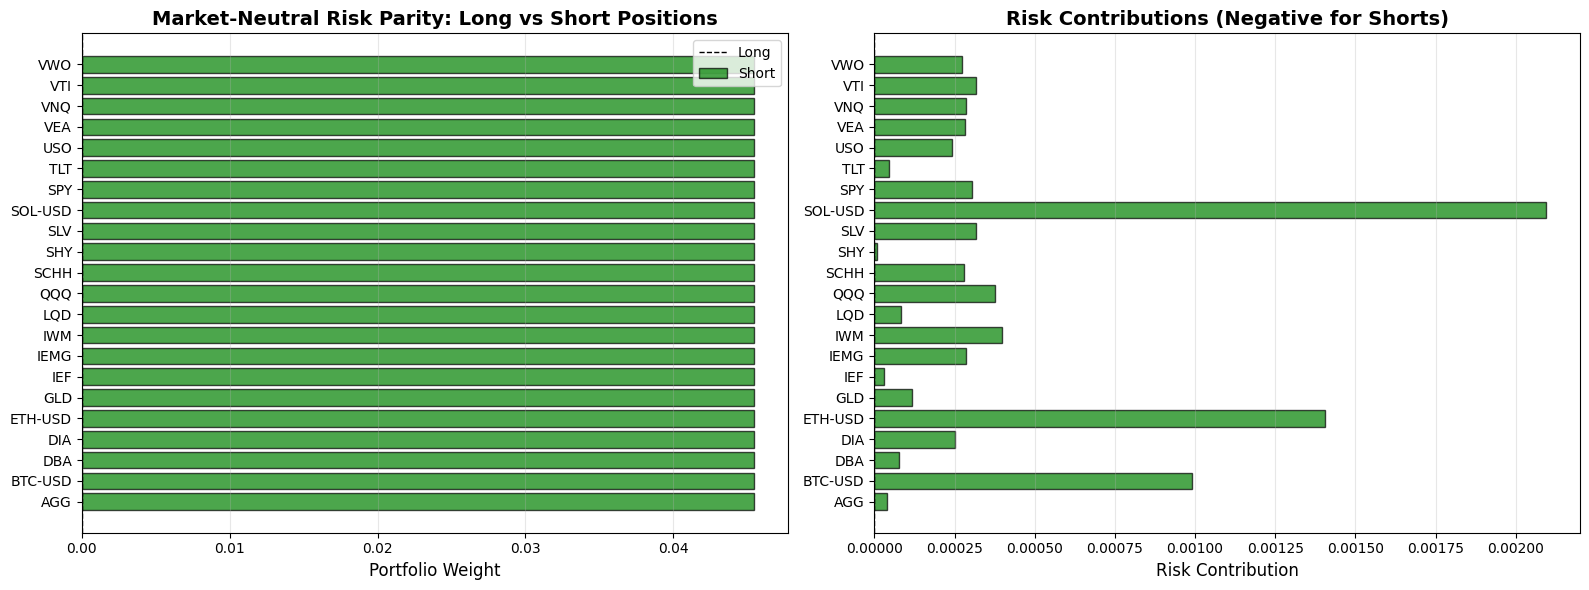


Comparison: Market-Neutral vs Long-Only Risk Parity

Target: 4.55% per asset (equal risk contribution)
Risk Parity Portfolio Performance:
Expected Return (annualized): 10.5838%
Volatility (annualized): 9.9443%
Sharpe Ratio (annualized): 0.8632
         Metric Market-Neutral Long-Only
Expected Return       16.5595%  10.5838%
     Volatility       13.5051%   9.9443%
   Sharpe Ratio         1.0781    0.8632
   Net Exposure       1.000000  1.000000


In [18]:
# Visualize Market-Neutral Portfolio
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Long vs Short Positions
ax1 = axes[0]
colors = ['green' if w > 0 else 'red' for w in mn_weights]
ax1.barh(large_institutional_ret_df.columns, mn_weights, color=colors, alpha=0.7, edgecolor='black')
ax1.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax1.set_xlabel('Portfolio Weight', fontsize=12)
ax1.set_title('Market-Neutral Risk Parity: Long vs Short Positions', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')
ax1.legend(['Long', 'Short'], loc='best')

# Plot 2: Risk Contributions
ax2 = axes[1]
risk_contribs_values = [risk_contribs[asset] for asset in large_institutional_ret_df.columns]
colors_rc = ['green' if rc > 0 else 'red' for rc in risk_contribs_values]
ax2.barh(large_institutional_ret_df.columns, risk_contribs_values, color=colors_rc, alpha=0.7, edgecolor='black')
ax2.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel('Risk Contribution', fontsize=12)
ax2.set_title('Risk Contributions (Negative for Shorts)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x') 

plt.tight_layout()
plt.show()

# Compare with long-only Risk Parity
print("\n" + "=" * 60)
print("Comparison: Market-Neutral vs Long-Only Risk Parity")
print("=" * 60)

# Fit Risk Parity optimizer
rp = RiskParity()
rp.fit(large_institutional_ret_df)

# Get portfolio weights
rp_weights = rp.predict()
rp_weights_dict = rp.get_weights_dict()

# Check risk contributions (should be approximately equal)
risk_contribs = rp.get_risk_contribution_percentages()
print(f"\nTarget: {100/len(large_institutional_ret_df.columns):.2f}% per asset (equal risk contribution)")

# Calculate Risk Parity portfolio performance
rp_return, rp_vol, rp_sharpe = rp.portfolio_performance(risk_free_rate=0.02)

print("Risk Parity Portfolio Performance:")
print(f"Expected Return (annualized): {rp_return:.4%}")
print(f"Volatility (annualized): {rp_vol:.4%}")
print(f"Sharpe Ratio (annualized): {rp_sharpe:.4f}")
comparison_mn = pd.DataFrame({
    'Metric': ['Expected Return', 'Volatility', 'Sharpe Ratio', 'Net Exposure'],
    'Market-Neutral': [f"{mn_return:.4%}", f"{mn_vol:.4%}", f"{mn_sharpe:.4f}", f"{mn_weights.sum():.6f}"],
    'Long-Only': [f"{rp_return:.4%}", f"{rp_vol:.4%}", f"{rp_sharpe:.4f}", "1.000000"]
})
print(comparison_mn.to_string(index=False))


## Comprehensive Risk-Return Analysis

This section provides a comprehensive comparison of all portfolio construction methods across all use cases, including both unleveraged and leveraged portfolios.

**Metrics Included:**
- Expected Return (annualized)
- Volatility (annualized)
- Sharpe Ratio
- Information Ratio (for RE-HRP)
- Maximum Drawdown


COMPREHENSIVE RISK-RETURN ANALYSIS: USE CASE 1 (MULTI-ASSET PORTFOLIO)

Primary Metrics: Risk-Adjusted Returns, Volatility, and Information Capture
+--------------------------------------------+-----------------------+---------------------------+----------------+---------------------+----------------+---------------------+
| Method                                     | Return (Annualized)   | Volatility (Annualized)   |   Sharpe Ratio |   Information Ratio | Max Drawdown   |   Return/Risk Ratio |
+============================================+=======================+===========================+================+=====================+================+=====================+
| Use Case 1: HRP                            | 0.9818%               | 5.8502%                   |        -0.174  |             -1.2894 | -20.4461%      |              0.1678 |
+--------------------------------------------+-----------------------+---------------------------+----------------+---------------------+-------

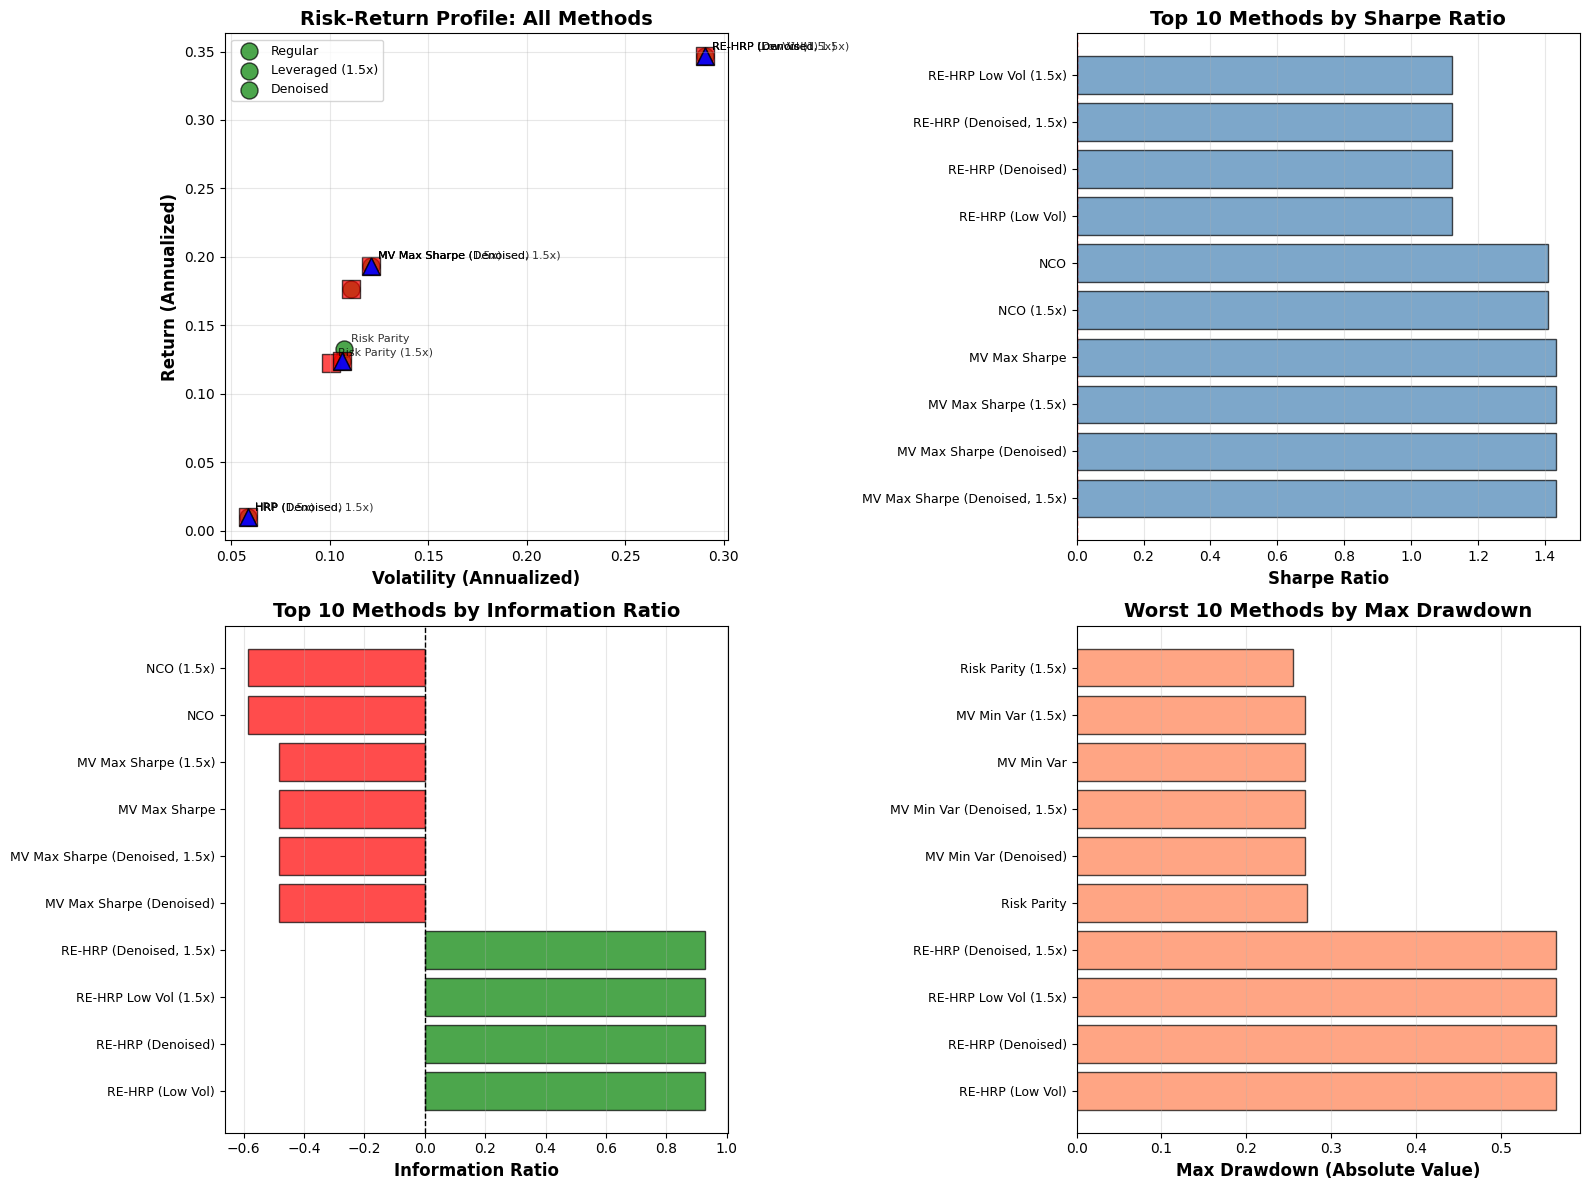


MATHEMATICAL VERIFICATION: PORTFOLIO WEIGHT CONSTRAINTS
Verifying that all portfolio weights satisfy required constraints:
------------------------------------------------------------------------------------------------------------------------
                        Method Sum of Weights Min Weight Max Weight Valid
                           HRP       1.000000   0.000079   0.551175     ✓
                   Risk Parity       1.000000   0.015203   0.103936     ✓
                           NCO       1.000000   0.000000   0.330977     ✓
              RE-HRP (Low Vol)       1.000000   0.017449   0.164806     ✓
                 MV Max Sharpe       1.000000   0.000000   0.386583     ✓
                    MV Min Var       1.000000   0.000000   0.106457     ✓
                    HRP (1.5x)       1.500000   0.000119   0.826763     ✓
            Risk Parity (1.5x)       1.000000   0.016657   0.112873     ✓
                    NCO (1.5x)       1.500000   0.000000   0.496466     ✓
         RE-HRP

In [18]:
# Comprehensive Risk-Return Analysis
# Compare all methods across all use cases

from tabulate import tabulate

def calculate_comprehensive_metrics(weights, returns_df, method_name, equal_weights=None):
    """Calculate comprehensive portfolio metrics"""
    if equal_weights is None:
        equal_weights = np.ones(len(returns_df.columns)) / len(returns_df.columns)
    
    # Portfolio returns
    port_returns = weighted_portfolio_returns(returns_df, weights)
    
    # Annualized metrics
    annual_return = portfolio_expected_return(returns_df, weights) * 252
    annual_vol = portfolio_volatility(returns_df, weights) * np.sqrt(252)
    sharpe = (annual_return - 0.02) / annual_vol if annual_vol > 0 else 0
    
    # Maximum drawdown
    cumulative = (1 + port_returns).cumprod()
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / running_max
    max_dd = drawdown.min()
    
    # Information ratio (vs equal-weighted benchmark)
    benchmark_returns = weighted_portfolio_returns(returns_df, equal_weights)
    excess_returns = port_returns - benchmark_returns
    tracking_error = excess_returns.std() * np.sqrt(252)
    info_ratio = (annual_return - (portfolio_expected_return(returns_df, equal_weights) * 252)) / tracking_error if tracking_error > 0 else 0
    
    return {
        'Method': method_name,
        'Return (Annualized)': annual_return,
        'Volatility (Annualized)': annual_vol,
        'Sharpe Ratio': sharpe,
        'Information Ratio': info_ratio,
        'Max Drawdown': max_dd,
        'Return/Risk Ratio': annual_return / annual_vol if annual_vol > 0 else 0
    }

# Collect all portfolios from Use Case 1 (Multi-Asset)
use_case_1_methods = [
    (multi_hrp_weights, 'Use Case 1: HRP'),
    (multi_rp_weights, 'Use Case 1: Risk Parity'),
    (multi_nco_weights, 'Use Case 1: NCO'),
    (multi_re_hrp_lowvol_weights, 'Use Case 1: RE-HRP (Low Vol)'),
    (mv_maxsharpe_weights, 'Use Case 1: MV Max Sharpe'),
    (mv_minvar_weights, 'Use Case 1: MV Min Var'),
    (multi_hrp_lev_weights, 'Use Case 1: HRP (1.5x)'),
    (multi_rp_lev_weights, 'Use Case 1: Risk Parity (1.5x)'),
    (multi_nco_lev_weights, 'Use Case 1: NCO (1.5x)'),
    (multi_re_hrp_lowvol_lev_weights, 'Use Case 1: RE-HRP Low Vol (1.5x)'),
    (mv_maxsharpe_lev_weights, 'Use Case 1: MV Max Sharpe (1.5x)'),
    (mv_minvar_lev_weights, 'Use Case 1: MV Min Var (1.5x)'),
    # Denoised versions (constant_residual)
    (multi_hrp_denoise_weights, 'Use Case 1: HRP (Denoised)'),
    (multi_re_hrp_denoise_weights, 'Use Case 1: RE-HRP (Denoised)'),
    (mv_maxsharpe_denoise_weights, 'Use Case 1: MV Max Sharpe (Denoised)'),
    (mv_minvar_denoise_weights, 'Use Case 1: MV Min Var (Denoised)'),
    # Leveraged Denoised versions
    (multi_hrp_denoise_lev_weights, 'Use Case 1: HRP (Denoised, 1.5x)'),
    (multi_re_hrp_denoise_lev_weights, 'Use Case 1: RE-HRP (Denoised, 1.5x)'),
    (mv_maxsharpe_denoise_lev_weights, 'Use Case 1: MV Max Sharpe (Denoised, 1.5x)'),
    (mv_minvar_denoise_lev_weights, 'Use Case 1: MV Min Var (Denoised, 1.5x)')
]

# Calculate metrics for all methods
metrics_list = []
equal_weights_multi = np.ones(len(multi_asset_returns.columns)) / len(multi_asset_returns.columns)

for weights, method_name in use_case_1_methods:
    metrics = calculate_comprehensive_metrics(weights, multi_asset_returns, method_name, equal_weights_multi)
    metrics_list.append(metrics)

# Create DataFrame
metrics_df = pd.DataFrame(metrics_list)

# Format for display
display_df = metrics_df.copy()
display_df['Return (Annualized)'] = display_df['Return (Annualized)'].apply(lambda x: f"{x:.4%}")
display_df['Volatility (Annualized)'] = display_df['Volatility (Annualized)'].apply(lambda x: f"{x:.4%}")
display_df['Sharpe Ratio'] = display_df['Sharpe Ratio'].apply(lambda x: f"{x:.4f}")
display_df['Information Ratio'] = display_df['Information Ratio'].apply(lambda x: f"{x:.4f}")
display_df['Max Drawdown'] = display_df['Max Drawdown'].apply(lambda x: f"{x:.4%}")
display_df['Return/Risk Ratio'] = display_df['Return/Risk Ratio'].apply(lambda x: f"{x:.4f}")

# Display using tabulate
print("=" * 120)
print("COMPREHENSIVE RISK-RETURN ANALYSIS: USE CASE 1 (MULTI-ASSET PORTFOLIO)")
print("=" * 120)
print("\nPrimary Metrics: Risk-Adjusted Returns, Volatility, and Information Capture")
print("=" * 120)
print(tabulate(display_df, headers='keys', tablefmt='grid', showindex=False))
print("=" * 120)

# Highlight key insights
print("\nKEY INSIGHTS:")
print("-" * 120)
print("1. Sharpe Ratio: Measures return per unit of risk (higher is better)")
print("2. Information Ratio: Measures risk-adjusted return vs equal-weighted benchmark")
print("3. Volatility: Primary risk metric - must be considered alongside returns")
print("4. Max Drawdown: Largest peak-to-trough decline (downside risk)")
print("5. Return/Risk Ratio: Simple risk-adjusted return measure")
print("6. Denoised methods use constant_residual approach to filter noise from covariance matrix")
print("=" * 120)

# Visualizations for Comprehensive Analysis
print("\n" + "=" * 120)
print("VISUALIZATIONS: RISK-RETURN ANALYSIS")
print("=" * 120)

# Create risk-return scatter plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Risk-Return Scatter (All Methods)
ax1 = axes[0, 0]
for idx, row in metrics_df.iterrows():
    color = 'blue' if 'Denoised' in row['Method'] else 'red' if '1.5x' in row['Method'] else 'green'
    marker = '^' if 'Denoised' in row['Method'] else 's' if '1.5x' in row['Method'] else 'o'
    ax1.scatter(row['Volatility (Annualized)'], row['Return (Annualized)'], 
               s=150, alpha=0.7, color=color, marker=marker, edgecolors='black', linewidth=1)
    # Add labels for key methods only
    if any(x in row['Method'] for x in ['HRP', 'Risk Parity', 'MV Max Sharpe', 'Equal-Weighted']):
        ax1.annotate(row['Method'].replace('Use Case 1: ', ''), 
                    (row['Volatility (Annualized)'], row['Return (Annualized)']),
                    fontsize=8, alpha=0.8, xytext=(5, 5), textcoords='offset points')

ax1.set_xlabel('Volatility (Annualized)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Return (Annualized)', fontsize=12, fontweight='bold')
ax1.set_title('Risk-Return Profile: All Methods', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(['Regular', 'Leveraged (1.5x)', 'Denoised'], loc='upper left', fontsize=9)

# Plot 2: Sharpe Ratio Comparison
ax2 = axes[0, 1]
sorted_sharpe = metrics_df.sort_values('Sharpe Ratio', ascending=False)
top_methods = sorted_sharpe.head(10)  # Top 10 by Sharpe
ax2.barh(range(len(top_methods)), top_methods['Sharpe Ratio'], 
        color='steelblue', alpha=0.7, edgecolor='black')
ax2.set_yticks(range(len(top_methods)))
ax2.set_yticklabels([m.replace('Use Case 1: ', '') for m in top_methods['Method']], fontsize=9)
ax2.set_xlabel('Sharpe Ratio', fontsize=12, fontweight='bold')
ax2.set_title('Top 10 Methods by Sharpe Ratio', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=1)

# Plot 3: Information Ratio Comparison
ax3 = axes[1, 0]
sorted_ir = metrics_df.sort_values('Information Ratio', ascending=False)
top_ir = sorted_ir.head(10)  # Top 10 by Information Ratio
colors_ir = ['green' if ir > 0 else 'red' for ir in top_ir['Information Ratio']]
ax3.barh(range(len(top_ir)), top_ir['Information Ratio'], 
        color=colors_ir, alpha=0.7, edgecolor='black')
ax3.set_yticks(range(len(top_ir)))
ax3.set_yticklabels([m.replace('Use Case 1: ', '') for m in top_ir['Method']], fontsize=9)
ax3.set_xlabel('Information Ratio', fontsize=12, fontweight='bold')
ax3.set_title('Top 10 Methods by Information Ratio', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')
ax3.axvline(x=0, color='black', linestyle='--', linewidth=1)

# Plot 4: Max Drawdown Comparison (lower is better, so we'll show absolute values)
ax4 = axes[1, 1]
sorted_dd = metrics_df.sort_values('Max Drawdown', ascending=True)  # Lower is better
worst_dd = sorted_dd.head(10)  # Worst 10 drawdowns
ax4.barh(range(len(worst_dd)), abs(worst_dd['Max Drawdown']), 
        color='coral', alpha=0.7, edgecolor='black')
ax4.set_yticks(range(len(worst_dd)))
ax4.set_yticklabels([m.replace('Use Case 1: ', '') for m in worst_dd['Method']], fontsize=9)
ax4.set_xlabel('Max Drawdown (Absolute Value)', fontsize=12, fontweight='bold')
ax4.set_title('Worst 10 Methods by Max Drawdown', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Mathematical Verification: Weight Constraints
print("\n" + "=" * 120)
print("MATHEMATICAL VERIFICATION: PORTFOLIO WEIGHT CONSTRAINTS")
print("=" * 120)
print("Verifying that all portfolio weights satisfy required constraints:")
print("-" * 120)

verification_results = []
for weights, method_name in use_case_1_methods:
    weight_sum = weights.sum()
    weight_min = weights.min()
    weight_max = weights.max()
    is_valid = (abs(weight_sum - 1.0) < 0.01 or abs(weight_sum - 1.5) < 0.01) and weight_min >= -0.01
    
    verification_results.append({
        'Method': method_name.replace('Use Case 1: ', ''),
        'Sum of Weights': f"{weight_sum:.6f}",
        'Min Weight': f"{weight_min:.6f}",
        'Max Weight': f"{weight_max:.6f}",
        'Valid': '✓' if is_valid else '✗'
    })

verification_df = pd.DataFrame(verification_results)
print(verification_df.to_string(index=False))
print("\n✓ = Valid (weights sum to ~1.0 or ~1.5 for leveraged, all weights >= 0)")
print("=" * 120)


## Out-of-Sample Volatility Forecasting and Accuracy

**Primary Focus**: Portfolio allocation success is measured by how accurately we can forecast portfolio volatility out-of-sample. This is the key metric for risk management.

**Why Out-of-Sample Volatility Matters:**
- In-sample volatility can be misleading (overfitting)
- Out-of-sample volatility reflects true portfolio risk
- Accurate volatility forecasts enable proper risk budgeting
- Better volatility forecasts → better risk-adjusted returns

**Metrics:**
- **Forecasted Volatility**: Predicted portfolio volatility using in-sample data
- **Realized Volatility**: Actual portfolio volatility in out-of-sample period
- **Forecast Error**: Difference between forecasted and realized volatility
- **Forecast Accuracy**: How well we predict portfolio risk (lower error = better)


In [20]:
# Out-of-Sample Volatility Forecasting and Accuracy Analysis
# Use Case 1: Multi-Asset Portfolio
# Split data into training (in-sample) and testing (out-of-sample) periods

# Use 70% for training, 30% for testing
split_idx = int(len(multi_asset_returns) * 0.7)
train_returns = multi_asset_returns.iloc[:split_idx]
test_returns = multi_asset_returns.iloc[split_idx:]

print("Out-of-Sample Volatility Forecasting Analysis")
print("=" * 100)
print(f"Training Period: {train_returns.index[0].date()} to {train_returns.index[-1].date()} ({len(train_returns)} days)")
print(f"Testing Period: {test_returns.index[0].date()} to {test_returns.index[-1].date()} ({len(test_returns)} days)")
print("=" * 100)

def calculate_volatility_forecast_accuracy(weights, train_returns, test_returns, method_name):
    """
    Calculate in-sample forecasted volatility vs out-of-sample realized volatility
    """
    # In-sample: Forecast volatility using training data
    forecasted_vol = portfolio_volatility(train_returns, weights) * np.sqrt(252)
    
    # Out-of-sample: Realized volatility using test data
    test_portfolio_returns = weighted_portfolio_returns(test_returns, weights)
    realized_vol = test_portfolio_returns.std() * np.sqrt(252)
    
    # Forecast error and accuracy
    forecast_error = abs(forecasted_vol - realized_vol)
    forecast_error_pct = (forecast_error / realized_vol * 100) if realized_vol > 0 else 0
    forecast_accuracy = 1 - (forecast_error / realized_vol) if realized_vol > 0 else 0
    
    # In-sample realized volatility (for comparison)
    train_portfolio_returns = weighted_portfolio_returns(train_returns, weights)
    in_sample_realized_vol = train_portfolio_returns.std() * np.sqrt(252)
    
    return {
        'Method': method_name,
        'Forecasted Vol (In-Sample)': forecasted_vol,
        'Realized Vol (Out-of-Sample)': realized_vol,
        'Realized Vol (In-Sample)': in_sample_realized_vol,
        'Forecast Error (Abs)': forecast_error,
        'Forecast Error (%)': forecast_error_pct,
        'Forecast Accuracy': forecast_accuracy,
        'Volatility Ratio (Out/In)': realized_vol / forecasted_vol if forecasted_vol > 0 else 0
    }

# Calculate volatility forecasts for all methods
# We need to refit on training data for each method
vol_forecast_list = []

# Equal Weighted
equal_weights_train = np.ones(len(train_returns.columns)) / len(train_returns.columns)
metrics = calculate_volatility_forecast_accuracy(equal_weights_train, train_returns, test_returns, 'Equal Weighted')
vol_forecast_list.append(metrics)

# HRP
hrp_train = HierarchicalRiskParity()
hrp_train.fit(train_returns)
hrp_weights_train = hrp_train.predict()
metrics = calculate_volatility_forecast_accuracy(hrp_weights_train, train_returns, test_returns, 'HRP')
vol_forecast_list.append(metrics)

# Risk Parity
rp_train = RiskParity()
rp_train.fit(train_returns)
rp_weights_train = rp_train.predict()
metrics = calculate_volatility_forecast_accuracy(rp_weights_train, train_returns, test_returns, 'Risk Parity')
vol_forecast_list.append(metrics)

# NCO
nco_train = NestedClusteredOptimization(n_clusters=3)
nco_train.fit(train_returns)
nco_weights_train = nco_train.predict()
metrics = calculate_volatility_forecast_accuracy(nco_weights_train, train_returns, test_returns, 'NCO')
vol_forecast_list.append(metrics)

# RE-HRP Low Vol
re_hrp_train = ReturnEnhancedHRP(
    linkage_method='ward',
    risk_free_rate=0.02,
    allocation_metric='information_ratio',
    verbose=False,
    min_return_threshold=0.05,
    min_tracking_error=0.01
)
re_hrp_train.fit(train_returns)
re_hrp_weights_train = re_hrp_train.predict()
metrics = calculate_volatility_forecast_accuracy(re_hrp_weights_train, train_returns, test_returns, 'RE-HRP (Low Vol)')
vol_forecast_list.append(metrics)

# Mean-Variance Max Sharpe
train_exp_returns = train_returns.mean().values
train_cov = train_returns.cov().values
def neg_sharpe(w):
    ret = train_exp_returns.T @ w
    vol = np.sqrt(w.T @ train_cov @ w)
    return -(ret - 0.02/252) / vol if vol > 0 else 1e10
mv_maxsharpe_result = minimize(neg_sharpe, equal_weights_train,
                               method='SLSQP', bounds=tuple((0,1) for _ in range(len(train_returns.columns))),
                               constraints=({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}))
mv_maxsharpe_weights_train = mv_maxsharpe_result.x
metrics = calculate_volatility_forecast_accuracy(mv_maxsharpe_weights_train, train_returns, test_returns, 'MV Max Sharpe')
vol_forecast_list.append(metrics)

# Mean-Variance Min Var
def port_var(w):
    return w.T @ train_cov @ w
mv_minvar_result = minimize(port_var, equal_weights_train,
                            method='SLSQP', bounds=tuple((0,1) for _ in range(len(train_returns.columns))),
                            constraints=({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}))
mv_minvar_weights_train = mv_minvar_result.x
metrics = calculate_volatility_forecast_accuracy(mv_minvar_weights_train, train_returns, test_returns, 'MV Min Var')
vol_forecast_list.append(metrics)

# Leveraged Portfolios (1.5x)
# Risk Parity Leveraged
rp_lev_train = RiskParity(leverage=1.5)
rp_lev_train.fit(train_returns)
rp_lev_weights_train = rp_lev_train.predict()
metrics = calculate_volatility_forecast_accuracy(rp_lev_weights_train, train_returns, test_returns, 'Risk Parity (1.5x)')
vol_forecast_list.append(metrics)

# HRP Leveraged
hrp_lev_weights_train = hrp_weights_train * 1.5
metrics = calculate_volatility_forecast_accuracy(hrp_lev_weights_train, train_returns, test_returns, 'HRP (1.5x)')
vol_forecast_list.append(metrics)

# NCO Leveraged
nco_lev_weights_train = nco_weights_train * 1.5
metrics = calculate_volatility_forecast_accuracy(nco_lev_weights_train, train_returns, test_returns, 'NCO (1.5x)')
vol_forecast_list.append(metrics)

# RE-HRP Low Vol Leveraged
re_hrp_lev_weights_train = re_hrp_weights_train * 1.5
metrics = calculate_volatility_forecast_accuracy(re_hrp_lev_weights_train, train_returns, test_returns, 'RE-HRP Low Vol (1.5x)')
vol_forecast_list.append(metrics)

# MV Max Sharpe Leveraged
mv_maxsharpe_lev_weights_train = mv_maxsharpe_weights_train * 1.5
metrics = calculate_volatility_forecast_accuracy(mv_maxsharpe_lev_weights_train, train_returns, test_returns, 'MV Max Sharpe (1.5x)')
vol_forecast_list.append(metrics)

# MV Min Var Leveraged
mv_minvar_lev_weights_train = mv_minvar_weights_train * 1.5
metrics = calculate_volatility_forecast_accuracy(mv_minvar_lev_weights_train, train_returns, test_returns, 'MV Min Var (1.5x)')
vol_forecast_list.append(metrics)

# Denoised Portfolios (constant_residual method)
denoiser_train = CovarianceDenoiser()
num_obs_train = len(train_returns)

# HRP with Denoising
hrp_denoise_train = HierarchicalRiskParity(denoise=True, denoising_method="constant_residual")
hrp_denoise_train.fit(train_returns)
hrp_denoise_weights_train = hrp_denoise_train.predict()
metrics = calculate_volatility_forecast_accuracy(hrp_denoise_weights_train, train_returns, test_returns, 'HRP (Denoised)')
vol_forecast_list.append(metrics)

# RE-HRP with Denoising
re_hrp_denoise_train = ReturnEnhancedHRP(
    linkage_method='ward',
    risk_free_rate=0.02,
    allocation_metric='information_ratio',
    verbose=False,
    min_return_threshold=0.05,
    min_tracking_error=0.01,
    denoise=True,
    denoising_method="constant_residual"
)
re_hrp_denoise_train.fit(train_returns)
re_hrp_denoise_weights_train = re_hrp_denoise_train.predict()
metrics = calculate_volatility_forecast_accuracy(re_hrp_denoise_weights_train, train_returns, test_returns, 'RE-HRP (Denoised)')
vol_forecast_list.append(metrics)

# Mean-Variance with Denoised Covariance
train_corr_matrix = train_returns.corr()
train_daily_vols = train_returns.std()

train_corr_denoised = denoiser_train.denoise(
    train_corr_matrix,
    method="constant_residual",
    num_observations=num_obs_train,
    matrix_type="correlation"
)

train_cov_denoised = denoiser_train._rescale_to_covariance(train_corr_denoised, train_daily_vols)
train_denoised_cov_matrix = train_cov_denoised.values
train_denoised_expected_returns = train_returns.mean().values

def mv_denoise_neg_sharpe(w):
    ret = train_denoised_expected_returns.T @ w
    vol = np.sqrt(w.T @ train_denoised_cov_matrix @ w)
    return -(ret - 0.02/252) / vol if vol > 0 else 1e10

mv_maxsharpe_denoise_result = minimize(mv_denoise_neg_sharpe, equal_weights_train,
                                       method='SLSQP', bounds=tuple((0,1) for _ in range(len(train_returns.columns))),
                                       constraints=({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}))
mv_maxsharpe_denoise_weights_train = mv_maxsharpe_result.x
metrics = calculate_volatility_forecast_accuracy(mv_maxsharpe_denoise_weights_train, train_returns, test_returns, 'MV Max Sharpe (Denoised)')
vol_forecast_list.append(metrics)

def mv_denoise_port_var(w):
    return w.T @ train_denoised_cov_matrix @ w

mv_minvar_denoise_result = minimize(mv_denoise_port_var, equal_weights_train,
                                    method='SLSQP', bounds=tuple((0,1) for _ in range(len(train_returns.columns))),
                                    constraints=({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}))
mv_minvar_denoise_weights_train = mv_minvar_denoise_result.x
metrics = calculate_volatility_forecast_accuracy(mv_minvar_denoise_weights_train, train_returns, test_returns, 'MV Min Var (Denoised)')
vol_forecast_list.append(metrics)

# Leveraged Denoised Portfolios (1.5x)
hrp_denoise_lev_weights_train = hrp_denoise_weights_train * 1.5
metrics = calculate_volatility_forecast_accuracy(hrp_denoise_lev_weights_train, train_returns, test_returns, 'HRP (Denoised, 1.5x)')
vol_forecast_list.append(metrics)

re_hrp_denoise_lev_weights_train = re_hrp_denoise_weights_train * 1.5
metrics = calculate_volatility_forecast_accuracy(re_hrp_denoise_lev_weights_train, train_returns, test_returns, 'RE-HRP (Denoised, 1.5x)')
vol_forecast_list.append(metrics)

mv_maxsharpe_denoise_lev_weights_train = mv_maxsharpe_denoise_weights_train * 1.5
metrics = calculate_volatility_forecast_accuracy(mv_maxsharpe_denoise_lev_weights_train, train_returns, test_returns, 'MV Max Sharpe (Denoised, 1.5x)')
vol_forecast_list.append(metrics)

mv_minvar_denoise_lev_weights_train = mv_minvar_denoise_weights_train * 1.5
metrics = calculate_volatility_forecast_accuracy(mv_minvar_denoise_lev_weights_train, train_returns, test_returns, 'MV Min Var (Denoised, 1.5x)')
vol_forecast_list.append(metrics)

# Create DataFrame
vol_forecast_df = pd.DataFrame(vol_forecast_list)

# Format for display
display_vol_df = vol_forecast_df.copy()
display_vol_df['Forecasted Vol (In-Sample)'] = display_vol_df['Forecasted Vol (In-Sample)'].apply(lambda x: f"{x:.4%}")
display_vol_df['Realized Vol (Out-of-Sample)'] = display_vol_df['Realized Vol (Out-of-Sample)'].apply(lambda x: f"{x:.4%}")
display_vol_df['Realized Vol (In-Sample)'] = display_vol_df['Realized Vol (In-Sample)'].apply(lambda x: f"{x:.4%}")
display_vol_df['Forecast Error (Abs)'] = display_vol_df['Forecast Error (Abs)'].apply(lambda x: f"{x:.4%}")
display_vol_df['Forecast Error (%)'] = display_vol_df['Forecast Error (%)'].apply(lambda x: f"{x:.2f}%")
display_vol_df['Forecast Accuracy'] = display_vol_df['Forecast Accuracy'].apply(lambda x: f"{x:.4f}")
display_vol_df['Volatility Ratio (Out/In)'] = display_vol_df['Volatility Ratio (Out/In)'].apply(lambda x: f"{x:.4f}")

# Display using tabulate
print("\n" + "=" * 120)
print("OUT-OF-SAMPLE VOLATILITY FORECASTING ACCURACY")
print("=" * 120)
print("\nPrimary Metric: How accurately do we forecast portfolio volatility?")
print("Lower Forecast Error = Better Risk Management")
print("=" * 120)
print(tabulate(display_vol_df, headers='keys', tablefmt='grid', showindex=False))
print("=" * 120)

# Rank by forecast accuracy
print("\nRANKING BY VOLATILITY FORECAST ACCURACY (Best to Worst):")
print("-" * 120)
ranked = vol_forecast_df.sort_values('Forecast Accuracy', ascending=False)
for i, (idx, row) in enumerate(ranked.iterrows(), 1):
    print(f"{i}. {row['Method']:30s} - Accuracy: {row['Forecast Accuracy']:.4f}, Error: {row['Forecast Error (%)']:.2f}%")
print("=" * 120)


Out-of-Sample Volatility Forecasting Analysis
Training Period: 2020-04-11 to 2024-04-10 (1461 days)
Testing Period: 2024-04-11 to 2025-12-29 (627 days)
RE-HRP: Information Ratio Allocation
Benchmark: Equal-weighted portfolio of 12 assets
Allocation Metric: Information Ratio
Formula: α = IR_right / (IR_left + IR_right)
Information Ratio = (E[R_portfolio] - E[R_benchmark]) / Tracking_Error
assets if the benchmark performs well. Consider using 'sharpe' instead.

RE-HRP Allocation Summary
Allocation complete. Portfolio weights favor clusters with higher Information Ratios.
Top weighted assets:
  1. ETH-USD: 0.1934 (19.34%)
  2. SOL-USD: 0.1528 (15.28%)
  3. TLT: 0.1000 (10.00%)
  4. AGG: 0.0900 (9.00%)
  5. BTC-USD: 0.0867 (8.67%)
RE-HRP: Information Ratio Allocation
Benchmark: Equal-weighted portfolio of 12 assets
Allocation Metric: Information Ratio
Formula: α = IR_right / (IR_left + IR_right)
Information Ratio = (E[R_portfolio] - E[R_benchmark]) / Tracking_Error
assets if the benchmark 

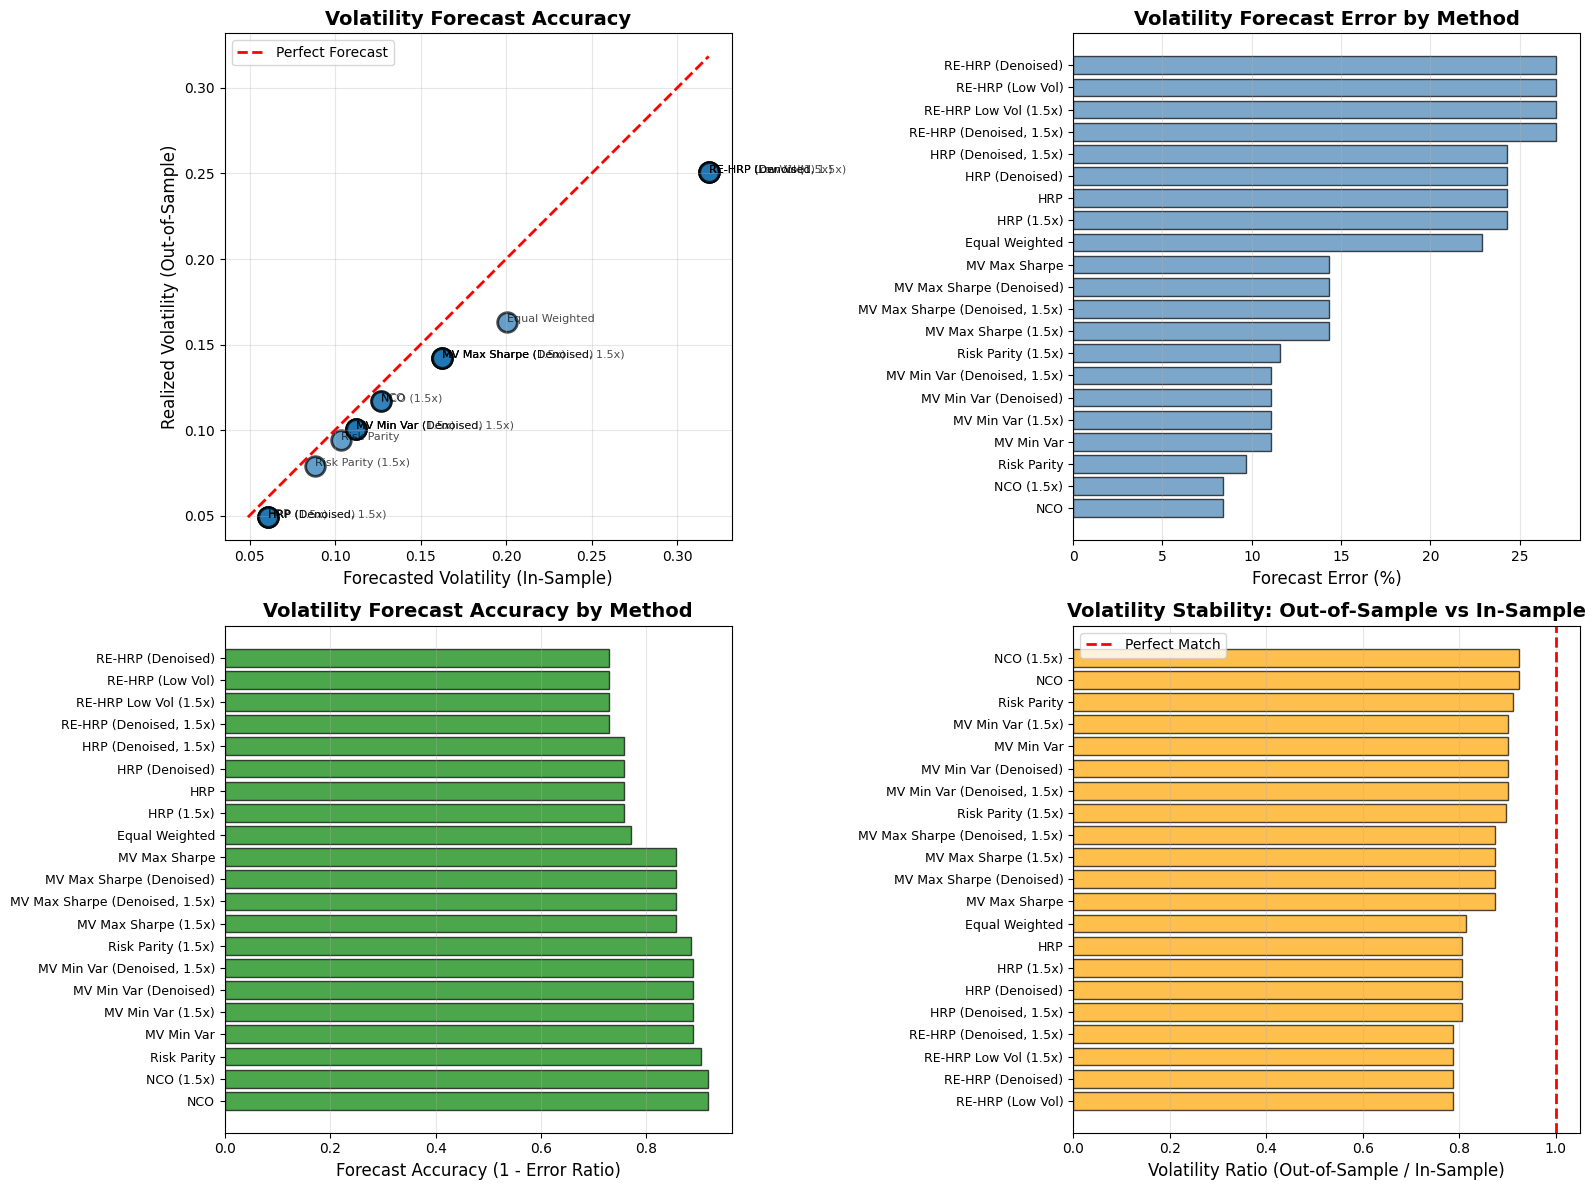


KEY INSIGHTS: OUT-OF-SAMPLE VOLATILITY FORECASTING
1. Lower Forecast Error = Better Risk Management
2. Forecast Accuracy close to 1.0 = Accurate volatility predictions
3. Volatility Ratio close to 1.0 = Stable risk profile across time periods
4. Methods with better forecast accuracy provide more reliable risk estimates


In [21]:
# Visualize Out-of-Sample Volatility Forecast Accuracy
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Forecasted vs Realized Volatility
ax1 = axes[0, 0]
ax1.scatter(vol_forecast_df['Forecasted Vol (In-Sample)'], 
           vol_forecast_df['Realized Vol (Out-of-Sample)'],
           s=200, alpha=0.7, edgecolors='black', linewidth=2)
# Perfect forecast line
min_vol = min(vol_forecast_df['Forecasted Vol (In-Sample)'].min(), 
              vol_forecast_df['Realized Vol (Out-of-Sample)'].min())
max_vol = max(vol_forecast_df['Forecasted Vol (In-Sample)'].max(), 
              vol_forecast_df['Realized Vol (Out-of-Sample)'].max())
ax1.plot([min_vol, max_vol], [min_vol, max_vol], 'r--', linewidth=2, label='Perfect Forecast')
ax1.set_xlabel('Forecasted Volatility (In-Sample)', fontsize=12)
ax1.set_ylabel('Realized Volatility (Out-of-Sample)', fontsize=12)
ax1.set_title('Volatility Forecast Accuracy', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
# Add method labels
for idx, row in vol_forecast_df.iterrows():
    ax1.annotate(row['Method'], 
                (row['Forecasted Vol (In-Sample)'], row['Realized Vol (Out-of-Sample)']),
                fontsize=8, alpha=0.7)

# Plot 2: Forecast Error by Method
ax2 = axes[0, 1]
sorted_df = vol_forecast_df.sort_values('Forecast Error (%)')
ax2.barh(range(len(sorted_df)), sorted_df['Forecast Error (%)'], 
        color='steelblue', alpha=0.7, edgecolor='black')
ax2.set_yticks(range(len(sorted_df)))
ax2.set_yticklabels(sorted_df['Method'], fontsize=9)
ax2.set_xlabel('Forecast Error (%)', fontsize=12)
ax2.set_title('Volatility Forecast Error by Method', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

# Plot 3: Forecast Accuracy by Method
ax3 = axes[1, 0]
sorted_df_acc = vol_forecast_df.sort_values('Forecast Accuracy', ascending=False)
ax3.barh(range(len(sorted_df_acc)), sorted_df_acc['Forecast Accuracy'], 
        color='green', alpha=0.7, edgecolor='black')
ax3.set_yticks(range(len(sorted_df_acc)))
ax3.set_yticklabels(sorted_df_acc['Method'], fontsize=9)
ax3.set_xlabel('Forecast Accuracy (1 - Error Ratio)', fontsize=12)
ax3.set_title('Volatility Forecast Accuracy by Method', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')

# Plot 4: Volatility Ratio (Out-of-Sample / In-Sample)
ax4 = axes[1, 1]
sorted_df_ratio = vol_forecast_df.sort_values('Volatility Ratio (Out/In)')
ax4.barh(range(len(sorted_df_ratio)), sorted_df_ratio['Volatility Ratio (Out/In)'], 
        color='orange', alpha=0.7, edgecolor='black')
ax4.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Perfect Match')
ax4.set_yticks(range(len(sorted_df_ratio)))
ax4.set_yticklabels(sorted_df_ratio['Method'], fontsize=9)
ax4.set_xlabel('Volatility Ratio (Out-of-Sample / In-Sample)', fontsize=12)
ax4.set_title('Volatility Stability: Out-of-Sample vs In-Sample', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n" + "=" * 120)
print("KEY INSIGHTS: OUT-OF-SAMPLE VOLATILITY FORECASTING")
print("=" * 120)
print("1. Lower Forecast Error = Better Risk Management")
print("2. Forecast Accuracy close to 1.0 = Accurate volatility predictions")
print("3. Volatility Ratio close to 1.0 = Stable risk profile across time periods")
print("4. Methods with better forecast accuracy provide more reliable risk estimates")
print("=" * 120)
